# Insurance Customer Support — Databricks Multi-Agent System
## Notebook : Agent Build, Test & Deployment

This notebook builds, tests, and deploys a **Supervisor-router Multi-Agent System**
for insurance customer support on Databricks.

### Architecture at a Glance
| Layer | Technology |
|---|---|
| LLM | Claude Sonnet 4.6 via Databricks Model Serving |
| Agent orchestration | LangGraph `StateGraph` with 6 specialist agents |
| Memory / checkpointing | Lakebase PostgreSQL via `PostgresSaver` |
| Knowledge retrieval | Databricks Vector Search (GTE Large, Delta Sync) |
| Data layer | Unity Catalog Delta Tables (6 tables, synthetic) |
| Deployment | MLflow PyFunc + `agents.deploy()` on Serverless V5 |
| Frontend | Databricks Apps (Streamlit) — see Notebook 2 |

### Specialist Agents
- **Policy Agent** — policy details, coverage, auto vehicle info
- **Billing Agent** — billing statements, payment history
- **Claims Agent** — claim filing, tracking, settlements
- **General Help Agent** — FAQ retrieval via Vector Search (RAG)
- **Human Escalation Agent** — empathetic handoff to a live agent
- **Final Answer Agent** — polishes and cleans the specialist response

### How to Run
Execute cells **top to bottom**.  
Sections marked **`[Vision]`** and **`[Deployment]`** can be run independently
after the core setup (Cells 1–32) is complete.  
**`[Debug]`** cells are standalone diagnostics — run only when needed.

---
> **Environment**: Databricks Serverless V5 · Python 3.11 · DBR 15.4+

## Section 1 — Environment Setup
Authentication, Unity Catalog schema/volume creation, Lakebase PostgreSQL connection.

In [0]:
# ── Cell 1: Authentication & Configuration ──────────────────────────────────

from databricks.sdk import WorkspaceClient

w = WorkspaceClient()

# ── Extract host and token from the SDK config object ─────────────────────────
_host = w.config.host
DATABRICKS_HOST = _host if _host.startswith("https://") else f"https://{_host}"
DATABRICKS_TOKEN = w.config.token

# ── Unity Catalog targets ──────────────────────────────────────────────────────
CATALOG = "main"
SCHEMA = "insurance_support"
FULL_SCHEMA = f"{CATALOG}.{SCHEMA}"

# ── Databricks Model Serving endpoint names ────────────────────────────────────
LLM_ENDPOINT = "databricks-claude-sonnet-4-6"
EMBEDDING_ENDPOINT = "databricks-gte-large-en"

# ── Vector Search client ───
from databricks.vector_search.client import VectorSearchClient

vsc = VectorSearchClient(disable_notice=True)

# ── Vector Search config ───────────────────────────────────────────────────────
VS_ENDPOINT_NAME = "insurance_vs_endpoint"
VS_INDEX_NAME = f"{FULL_SCHEMA}.insurance_faq_vs_index"
VS_SOURCE_TABLE = f"{FULL_SCHEMA}.insurance_faq"

# ── UC Volume config (persistent HF download cache) ───────────────────────────
VOLUME_NAME = "insurance_support_vol"
VOLUME_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME_NAME}"
HF_CACHE = f"{VOLUME_PATH}/hf_cache"

# ── Databricks Secrets scope for Lakebase credentials ─────────────────────────
SECRETS_SCOPE = "insurance_support"

print("✅ Config loaded")
print(f"   Workspace : {DATABRICKS_HOST}")
print(f"   Schema    : {FULL_SCHEMA}")
print(f"   Volume    : {VOLUME_PATH}")
print(f"   HF cache  : {HF_CACHE}")
print(f"   LLM       : {LLM_ENDPOINT}")
print(f"   Embedding : {EMBEDDING_ENDPOINT}")

✅ Config loaded
   Workspace : https://dbc-03ce2bc5-fcfa.cloud.databricks.com
   Schema    : main.insurance_support
   Volume    : /Volumes/main/insurance_support/insurance_support_vol
   HF cache  : /Volumes/main/insurance_support/insurance_support_vol/hf_cache
   LLM       : databricks-claude-sonnet-4-6
   Embedding : databricks-gte-large-en


In [0]:
# ── Cell 2: Create Unity Catalog Schema and UC Volume ───────────────────────

spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {FULL_SCHEMA}")
print(f"✅ Schema ready : {FULL_SCHEMA}")

# Create the UC managed Volume used as the persistent HF download cache.
spark.sql(f"CREATE VOLUME IF NOT EXISTS {CATALOG}.{SCHEMA}.{VOLUME_NAME}")
print(f"✅ Volume ready : {VOLUME_PATH}")
print(f"   HF cache    : {HF_CACHE}")

✅ Schema ready : main.insurance_support
✅ Volume ready : /Volumes/main/insurance_support/insurance_support_vol
   HF cache    : /Volumes/main/insurance_support/insurance_support_vol/hf_cache


In [0]:
# ── Cell 3: Discover Lakebase Connection Details & Store Credentials in Databricks Secrets

from urllib.parse import quote

LAKEBASE_INSTANCE_NAME = "insurance-support-pg"

# ── Discover ENDPOINT and HOST via w.postgres APIs ────────────────────────────
# list_projects → list_branches → list_endpoints gives us everything we need.

projects = list(w.postgres.list_projects())
project = next((p for p in projects if LAKEBASE_INSTANCE_NAME in p.name), projects[0])
print(f"Project : {project.name}")

branches = list(w.postgres.list_branches(parent=project.name))
branch = branches[0]
print(f"Branch  : {branch.name}")

endpoints = list(w.postgres.list_endpoints(parent=branch.name))
endpoint = endpoints[0]
print(f"Endpoint: {endpoint.name}")

pg_endpoint = endpoint.name
pg_host = endpoint.status.hosts.host
pg_dbname = "databricks_postgres"
pg_username = w.current_user.me().user_name

print(f"\nConnection details:")
print(f"   host     : {pg_host}")
print(f"   endpoint : {pg_endpoint}")
print(f"   dbname   : {pg_dbname}")
print(f"   username : {pg_username}")

# ── Delete scope if it already exists (clean slate) ─────────────────────────
try:
    existing_secrets = w.secrets.list_secrets(scope=SECRETS_SCOPE)
    for s in existing_secrets:
        w.secrets.delete_secret(scope=SECRETS_SCOPE, key=s.key)
        print(f"   🗑  Deleted secret : {SECRETS_SCOPE}/{s.key}")
    w.secrets.delete_scope(scope=SECRETS_SCOPE)
    print(f"   🗑  Deleted scope  : {SECRETS_SCOPE}")
except Exception as e:
    if "does not exist" in str(e).lower() or "not found" in str(e).lower():
        print(f"   ℹ️  Scope '{SECRETS_SCOPE}' does not exist yet — skipping delete")
    else:
        raise

# ── Create fresh scope ────────────────────────────────────────────────────────
w.secrets.create_scope(scope=SECRETS_SCOPE)
print(f"\n✅ Created secrets scope: {SECRETS_SCOPE}")

# ── Create a long-lived PAT for Lakebase authentication ──────────────────────
print("Creating PAT for Lakebase auth...")
token_resp = w.tokens.create(
    comment="Insurance Support Lakebase Auth",
    lifetime_seconds=60 * 60 * 24 * 365,  # 1 year
)
pg_password = token_resp.token_value

# ── Store all config + PAT in Secrets ─────────────────────────────────────────
for key, value in {
    "pg_host": pg_host,
    "pg_endpoint": pg_endpoint,
    "pg_dbname": pg_dbname,
    "pg_username": pg_username,
    "pg_password": pg_password,
}.items():
    w.secrets.put_secret(scope=SECRETS_SCOPE, key=key, string_value=value)
    print(f"   ✅ {SECRETS_SCOPE}/{key}")

# Clear PAT from memory immediately after storing
del pg_password, token_resp
print("\n✅ All config stored. PAT cleared from memory.")

Project : projects/insurance-support-pg
Branch  : projects/insurance-support-pg/branches/production
Endpoint: projects/insurance-support-pg/branches/production/endpoints/primary

Connection details:
   host     : ep-calm-cell-d1wr2dke.database.us-west-2.cloud.databricks.com
   endpoint : projects/insurance-support-pg/branches/production/endpoints/primary
   dbname   : databricks_postgres
   username : abhirup.pal93@gmail.com
   🗑  Deleted secret : insurance_support/pg_dbname
   🗑  Deleted secret : insurance_support/pg_endpoint
   🗑  Deleted secret : insurance_support/pg_host
   🗑  Deleted secret : insurance_support/pg_password
   🗑  Deleted secret : insurance_support/pg_username
   🗑  Deleted scope  : insurance_support

✅ Created secrets scope: insurance_support
Creating PAT for Lakebase auth...
   ✅ insurance_support/pg_host
   ✅ insurance_support/pg_endpoint
   ✅ insurance_support/pg_dbname
   ✅ insurance_support/pg_username
   ✅ insurance_support/pg_password

✅ All config stored. PA

In [0]:
# ── Cell 4: Connect to Lakebase PostgreSQL and Initialize LangGraph PostgresSaver Checkpointer 

import psycopg
from urllib.parse import quote
from langgraph.checkpoint.postgres import PostgresSaver

# ── Read static config from Secrets ───────────────────────────────────────────
PG_HOST = dbutils.secrets.get(scope=SECRETS_SCOPE, key="pg_host")
PG_ENDPOINT = dbutils.secrets.get(scope=SECRETS_SCOPE, key="pg_endpoint")
PG_DBNAME = dbutils.secrets.get(scope=SECRETS_SCOPE, key="pg_dbname")
PG_USERNAME = dbutils.secrets.get(scope=SECRETS_SCOPE, key="pg_username")

# ── Generate fresh OAuth credential for this session ──────────────────────────
cred = w.postgres.generate_database_credential(endpoint=PG_ENDPOINT)

# ── Build connection string ────────────────────────────────────────────────────
DB_URI = (
    f"postgresql://{quote(PG_USERNAME, safe='')}:{quote(cred.token, safe='')}"
    f"@{PG_HOST}:5432/{PG_DBNAME}"
    f"?sslmode=require"
)

# ── Step 1: Setup checkpoint tables using context manager ─────────────────────
with PostgresSaver.from_conn_string(DB_URI) as tmp:
    tmp.setup()
print("✅ Checkpoint tables ready in Lakebase")

# ── Step 2: Persistent connection for LangGraph ───────────────────────────────
pg_conn = psycopg.connect(DB_URI, autocommit=True)
checkpointer = PostgresSaver(pg_conn)

print(f"\n✅ Lakebase checkpointer ready")
print(f"   Host     : {PG_HOST}:5432")
print(f"   Database : {PG_DBNAME}")
print(f"   Tables   : checkpoints, checkpoint_blobs, checkpoint_writes")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-2cb246ca-9ee1-45f2-959f-bb4276039e75/lib/python3.12/site-packages/langgraph/checkpoint/postgres/__init__.py:10: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.base import (


✅ Checkpoint tables ready in Lakebase

✅ Lakebase checkpointer ready
   Host     : [REDACTED]:5432
   Database : [REDACTED]
   Tables   : checkpoints, checkpoint_blobs, checkpoint_writes


## Section 2 — Data Layer
Generate synthetic insurance data and write to Unity Catalog Delta tables.

In [0]:
# ── Cell 5: Generate Synthetic Insurance Data (customers, policies, billing, payments, claims) 

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random


def generate_sample_data(random_state=42):
    random.seed(random_state)
    np.random.seed(random_state)

    first_names = [
        "John",
        "Jane",
        "Robert",
        "Maria",
        "David",
        "Lisa",
        "Michael",
        "Sarah",
        "William",
        "Emma",
        "Joseph",
        "Olivia",
        "Charles",
        "Ava",
        "Thomas",
        "Isabella",
        "Matthew",
        "Sophia",
        "Anthony",
        "Charlotte",
        "Christopher",
        "Amelia",
        "Joshua",
        "Evelyn",
        "Ryan",
        "Abigail",
        "Brandon",
        "Ella",
        "Justin",
        "Scott",
        "Alexander",
        "Chloe",
        "Kevin",
        "Victoria",
        "Jason",
        "Lily",
        "Brian",
        "Hannah",
        "Kyle",
        "Zoey",
    ]
    last_names = [
        "Smith",
        "Johnson",
        "Williams",
        "Brown",
        "Jones",
        "Garcia",
        "Miller",
        "Davis",
        "Hernandez",
        "Lopez",
        "Gonzalez",
        "Wilson",
        "Anderson",
        "Thomas",
        "Taylor",
        "Lee",
        "Perez",
        "Thompson",
        "White",
        "Harris",
        "Sanchez",
        "Clark",
        "Ramirez",
        "Walker",
        "Young",
        "Allen",
        "King",
        "Wright",
        "Scott",
        "Torres",
        "Nguyen",
        "Green",
        "Adams",
        "Nelson",
        "Baker",
        "Hall",
        "Rivera",
        "Campbell",
        "Mitchell",
    ]

    customers = pd.DataFrame(
        {
            "customer_id": [f"CUST{str(i).zfill(5)}" for i in range(1, 1001)],
            "first_name": [random.choice(first_names) for _ in range(1000)],
            "last_name": [random.choice(last_names) for _ in range(1000)],
            "email": [f"user{i}@example.com" for i in range(1, 1001)],
            "phone": [
                f"555-{str(random.randint(100,999))}-{str(random.randint(1000,9999))}"
                for _ in range(1000)
            ],
            "date_of_birth": [
                (
                    datetime(1980, 1, 1) + timedelta(days=random.randint(0, 14600))
                ).strftime("%Y-%m-%d")
                for _ in range(1000)
            ],
            "state": [
                random.choice(["CA", "NY", "TX", "FL", "IL", "PA", "OH", "GA"])
                for _ in range(1000)
            ],
        }
    )

    policies = pd.DataFrame(
        {
            "policy_number": [f"POL{str(i).zfill(6)}" for i in range(1, 1501)],
            "customer_id": [
                f"CUST{str(random.randint(1,1000)).zfill(5)}" for _ in range(1500)
            ],
            "policy_type": [
                random.choice(["auto", "home", "life"]) for _ in range(1500)
            ],
            "start_date": [
                (
                    datetime(2023, 1, 1) + timedelta(days=random.randint(0, 365))
                ).strftime("%Y-%m-%d")
                for _ in range(1500)
            ],
            "premium_amount": [round(random.uniform(50, 500), 2) for _ in range(1500)],
            "billing_frequency": [
                random.choice(["monthly", "quarterly", "annual"]) for _ in range(1500)
            ],
            "status": [
                random.choice(["active", "active", "active", "cancelled"])
                for _ in range(1500)
            ],
        }
    )

    auto_policies = policies[policies["policy_type"] == "auto"].copy()
    auto_policy_details = pd.DataFrame(
        {
            "policy_number": auto_policies["policy_number"].values,
            "vehicle_vin": [
                f"VIN{random.randint(10000000000000000,99999999999999999)}"
                for _ in range(len(auto_policies))
            ],
            "vehicle_make": [
                random.choice(["Toyota", "Honda", "Ford", "Chevrolet", "Nissan"])
                for _ in range(len(auto_policies))
            ],
            "vehicle_model": [
                random.choice(["Camry", "Civic", "F-150", "Malibu", "Altima"])
                for _ in range(len(auto_policies))
            ],
            "vehicle_year": [
                random.randint(2015, 2023) for _ in range(len(auto_policies))
            ],
            "liability_limit": [
                random.choice([50000, 100000, 300000])
                for _ in range(len(auto_policies))
            ],
            "collision_deductible": [
                random.choice([250, 500, 1000]) for _ in range(len(auto_policies))
            ],
            "comprehensive_deductible": [
                random.choice([250, 500, 1000]) for _ in range(len(auto_policies))
            ],
            "uninsured_motorist": [
                random.choice([0, 1]) for _ in range(len(auto_policies))
            ],
            "rental_car_coverage": [
                random.choice([0, 1]) for _ in range(len(auto_policies))
            ],
        }
    )

    billing = pd.DataFrame(
        {
            "bill_id": [f"BILL{str(i).zfill(6)}" for i in range(1, 5001)],
            "policy_number": [
                random.choice(policies["policy_number"]) for _ in range(5000)
            ],
            "billing_date": [
                (
                    datetime(2024, 1, 1) + timedelta(days=random.randint(0, 364))
                ).strftime("%Y-%m-%d")
                for _ in range(5000)
            ],
            "due_date": [
                (
                    datetime(2024, 1, 15) + timedelta(days=random.randint(0, 364))
                ).strftime("%Y-%m-%d")
                for _ in range(5000)
            ],
            "amount_due": [round(random.uniform(100, 1000), 2) for _ in range(5000)],
            "status": [
                random.choice(["paid", "pending", "overdue"]) for _ in range(5000)
            ],
        }
    )

    payments = pd.DataFrame(
        {
            "payment_id": [f"PAY{str(i).zfill(6)}" for i in range(1, 4001)],
            "bill_id": [random.choice(billing["bill_id"]) for _ in range(4000)],
            "payment_date": [
                (
                    datetime(2024, 1, 1) + timedelta(days=random.randint(0, 364))
                ).strftime("%Y-%m-%d")
                for _ in range(4000)
            ],
            "amount": [round(random.uniform(50, 500), 2) for _ in range(4000)],
            "payment_method": [
                random.choice(["credit_card", "debit_card", "bank_transfer"])
                for _ in range(4000)
            ],
            "transaction_id": [
                f"TXN{random.randint(100000,999999)}" for _ in range(4000)
            ],
            "status": [
                random.choice(["completed", "pending", "failed"]) for _ in range(4000)
            ],
        }
    )

    claims = pd.DataFrame(
        {
            "claim_id": [f"CLM{str(i).zfill(6)}" for i in range(1, 301)],
            "policy_number": [
                random.choice(policies["policy_number"]) for _ in range(300)
            ],
            "claim_date": [
                (
                    datetime(2024, 1, 1) + timedelta(days=random.randint(0, 364))
                ).strftime("%Y-%m-%d")
                for _ in range(300)
            ],
            "incident_type": [
                random.choice(
                    ["collision", "theft", "property_damage", "medical", "liability"]
                )
                for _ in range(300)
            ],
            "estimated_loss": [
                round(random.uniform(500, 20000), 2) for _ in range(300)
            ],
            "status": [
                random.choice(
                    ["submitted", "under_review", "approved", "paid", "denied"]
                )
                for _ in range(300)
            ],
        }
    )

    return {
        "customers": customers,
        "policies": policies,
        "auto_policy_details": auto_policy_details,
        "billing": billing,
        "payments": payments,
        "claims": claims,
    }


sample_data = generate_sample_data()
print("✅ Synthetic data generated")
for tbl, df in sample_data.items():
    print(f"   {tbl}: {df.shape}")

✅ Synthetic data generated
   customers: (1000, 7)
   policies: (1500, 7)
   auto_policy_details: (505, 10)
   billing: (5000, 6)
   payments: (4000, 7)
   claims: (300, 6)


In [0]:
# ── Cell 6: Write Synthetic Data to Unity Catalog Delta Tables ──────────────

from pyspark.sql import functions as F


def write_delta_table(
    df_pandas: pd.DataFrame, table_name: str, mode: str = "overwrite"
):
    full_table = f"{FULL_SCHEMA}.{table_name}"
    df_spark = spark.createDataFrame(df_pandas)
    (
        df_spark.write.format("delta")
        .mode(mode)
        .option("overwriteSchema", "true")
        .saveAsTable(full_table)
    )
    count = spark.table(full_table).count()
    print(f"   ✅ {full_table} → {count} rows")


print("Writing Delta tables...")
for table_name, df in sample_data.items():
    write_delta_table(df, table_name)

print("\n✅ All Delta tables written to Unity Catalog")

Writing Delta tables...
   ✅ main.insurance_support.customers → 1000 rows
   ✅ main.insurance_support.policies → 1500 rows
   ✅ main.insurance_support.auto_policy_details → 505 rows
   ✅ main.insurance_support.billing → 5000 rows
   ✅ main.insurance_support.payments → 4000 rows
   ✅ main.insurance_support.claims → 300 rows

✅ All Delta tables written to Unity Catalog


In [0]:
# ── Cell 7: Verify Delta Tables — Row Counts and Schema ─────────────────────

display(spark.sql(f"SHOW TABLES IN {FULL_SCHEMA}"))

database,tableName,isTemporary
insurance_support,auto_policy_details,false
insurance_support,billing,false
insurance_support,claims,false
insurance_support,customers,false
insurance_support,payments,false
insurance_support,policies,false


## Section 3 — Vector Search & FAQ Knowledge Base
Download InsuranceQA-v2, write to Delta, create managed Vector Search index with GTE Large embeddings.

In [0]:
# ── Cell 8: Download InsuranceQA-v2 Dataset from Hugging Face to UC Volume ──

import glob
import os
import pandas as pd
from huggingface_hub import snapshot_download

# ── Download to UC Volume (persistent cache) ──────────────────────────────────

print(f"HF cache path : {HF_CACHE}")
print("Downloading insuranceQA-v2 from Hugging Face...")

local_path = snapshot_download(
    repo_id="deccan-ai/insuranceQA-v2",
    repo_type="dataset",
    local_dir=HF_CACHE,
    local_dir_use_symlinks=False,
    ignore_patterns=["*.md", "*.gitattributes"],
)
print(f"Downloaded to: {local_path}")

# ── Inspect every file actually downloaded ────────────────────────────────────
all_files = [
    os.path.join(root, fname)
    for root, _, files in os.walk(local_path)
    for fname in files
]
print(f"Files found ({len(all_files)}):")
for f in sorted(all_files):
    print(f"  {f}")

# ── Read data files — try parquet, jsonl, json in order ──────────────────────
parquet_files = sorted(glob.glob(f"{local_path}/**/*.parquet", recursive=True))
jsonl_files = sorted(glob.glob(f"{local_path}/**/*.jsonl", recursive=True))
json_files = sorted(glob.glob(f"{local_path}/**/*.json", recursive=True))

if parquet_files:
    print(f"Reading {len(parquet_files)} parquet file(s)...")
    df_faq = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)
elif jsonl_files:
    print(f"Reading {len(jsonl_files)} jsonl file(s)...")
    df_faq = pd.concat(
        [pd.read_json(f, lines=True) for f in jsonl_files], ignore_index=True
    )
elif json_files:
    print(f"Reading {len(json_files)} json file(s)...")
    df_faq = pd.concat([pd.read_json(f) for f in json_files], ignore_index=True)
else:
    raise FileNotFoundError(
        f"No readable data files found under {local_path}.\n"
        f"All files present: {sorted(all_files)}"
    )

print(f"Raw DataFrame shape : {df_faq.shape}")
print(f"Columns             : {list(df_faq.columns)}")

# ── Standardise column names ──────────────────────────────────────────────────
df_faq = df_faq.rename(columns={"input": "question", "output": "answer"})

# ── Build combined field (used for embedding by Vector Search) ─────────────────
df_faq["combined"] = (
    "Question: " + df_faq["question"] + " \nAnswer: " + df_faq["answer"]
)

# ── Sample and reset index ────────────────────────────────────────────────────
df_faq = df_faq.sample(500, random_state=42).reset_index(drop=True)

# Vector Search requires an integer primary key
df_faq.insert(0, "id", range(1, len(df_faq) + 1))

print(f"Final FAQ shape : {df_faq.shape}")
df_faq.head(3)

HF cache path : /Volumes/main/insurance_support/insurance_support_vol/hf_cache


/databricks/python/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Downloaded to: /Volumes/main/insurance_support/insurance_support_vol/hf_cache
Files found (10):
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/.gitignore
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/download/test.jsonl.lock
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/download/test.jsonl.metadata
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/download/train.jsonl.lock
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/download/train.jsonl.metadata
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/download/valid.jsonl.lock
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/.cache/huggingface/download/valid.jsonl.metadata
  /Volumes/main/insurance_support/insurance_support_vol/hf_cache/test.jsonl
  /Volumes/main/insurance_support/insurance_support_vol/hf_cach

,id,question,answer,combined
0,1,Are Retirement Plans Protected From Creditors?,ERISA is a federal law which dates back to 197...,Question: Are Retirement Plans Protected From ...
1,2,Does Homeowners Insurance Cover Hot Water Heat...,Typically a water heater will be covered if th...,Question: Does Homeowners Insurance Cover Hot ...
2,3,Is Disability Insurance Tax Free?,If you pay your disability insurance premium w...,Question: Is Disability Insurance Tax Free? \...


In [0]:
# ── Cell 9: Write FAQ Dataset to Unity Catalog Delta Table (Vector Search Source) 

FAQ_TABLE = f"{FULL_SCHEMA}.insurance_faq"

(
    spark.createDataFrame(df_faq)
    .write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .option("delta.enableChangeDataFeed", "true")
    .saveAsTable(FAQ_TABLE)
)

print(f"✅ FAQ table written: {FAQ_TABLE}")
print(f"   Row count: {spark.table(FAQ_TABLE).count()}")

✅ FAQ table written: main.insurance_support.insurance_faq
   Row count: 500


In [0]:
# ── Cell 10: Enable Change Data Feed on FAQ Table (Required for Delta Sync Index) 

spark.sql(
    f"""
    ALTER TABLE {FAQ_TABLE}
    SET TBLPROPERTIES (delta.enableChangeDataFeed = true)
"""
)

print("✅ Change Data Feed enabled on FAQ table")

✅ Change Data Feed enabled on FAQ table


In [0]:
# ── Cell 11: Create Vector Search Endpoint (idempotent — skips if already exists) 

try:
    vsc.get_endpoint(name=VS_ENDPOINT_NAME)
    print(f"⚠️  Endpoint '{VS_ENDPOINT_NAME}' already exists — skipping creation")
except Exception:
    print(f"Creating Vector Search endpoint '{VS_ENDPOINT_NAME}'...")
    vsc.create_endpoint_and_wait(
        name=VS_ENDPOINT_NAME,
        endpoint_type="STANDARD",
    )
    print(f"✅ Endpoint created: {VS_ENDPOINT_NAME}")

Creating Vector Search endpoint 'insurance_vs_endpoint'...
✅ Endpoint created: insurance_vs_endpoint


In [0]:
# ── Cell 12: Create Delta Sync Index with GTE Large Managed Embeddings (idempotent) 

try:
    vsc.get_index(endpoint_name=VS_ENDPOINT_NAME, index_name=VS_INDEX_NAME)
    print(f"⚠️  Index '{VS_INDEX_NAME}' already exists — skipping creation")
except Exception:
    print(f"Creating Vector Search index '{VS_INDEX_NAME}'...")
    vsc.create_delta_sync_index_and_wait(
        endpoint_name=VS_ENDPOINT_NAME,
        index_name=VS_INDEX_NAME,
        source_table_name=VS_SOURCE_TABLE,
        pipeline_type="TRIGGERED",
        primary_key="id",
        embedding_source_column="combined",
        embedding_model_endpoint_name=EMBEDDING_ENDPOINT,
    )
    print(f"✅ Vector Search index created: {VS_INDEX_NAME}")

Creating Vector Search index 'main.insurance_support.insurance_faq_vs_index'...
✅ Vector Search index created: main.insurance_support.insurance_faq_vs_index


In [0]:
# ── Cell 13: Optional: Trigger Initial Sync — Databricks Auto-Triggers on Index Creation (Commented Out)

# import time

# idx = vsc.get_index(endpoint_name=VS_ENDPOINT_NAME, index_name=VS_INDEX_NAME)

# print("Triggering initial sync of FAQ data into Vector Search index...")
# idx.sync()  # fires the sync pipeline

# # Poll until the index is ONLINE_NO_PENDING_UPDATE (sync complete)
# while True:
#     info        = idx.describe()
#     state       = info.get("status", {}).get("detailed_state", "UNKNOWN")
#     ready_count = info.get("status", {}).get("indexed_row_count", 0)
#     print(f"  Index state: {state} | rows indexed: {ready_count}")
#     if "ONLINE" in state and "PENDING" not in state:
#         break
#     time.sleep(15)

# print("✅ Vector Search index sync complete")

In [0]:
# ── Cell 14: Test Vector Search Retrieval — Smoke Test Before Agent Use ─────

idx = vsc.get_index(endpoint_name=VS_ENDPOINT_NAME, index_name=VS_INDEX_NAME)

test_response = idx.similarity_search(
    query_text="What does life insurance cover?",
    columns=["id", "question", "answer"],
    num_results=3,
)

col_names = [c["name"] for c in test_response["manifest"]["columns"]]
rows = test_response["result"]["data_array"]
print(f"Columns : {col_names}")
print(f"Results : {len(rows)} rows")
for row in rows:
    record = dict(zip(col_names, row))
    print(f"  Q: {str(record.get('question',''))[:80]}...")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Columns : ['id', 'question', 'answer', 'score']
Results : 3 rows
  Q: What Does Term Life Insurance Not Cover? ...
  Q: Does Life Insurance Cover Cancer Death? ...
  Q: Why Do We Have Life Insurance? ...


## Section 4 — LLM Client, Tool Functions & Prompt Templates
Initialize mlflow.deployments client, define Spark-based tool functions, and set all prompt templates.

In [0]:
# ── Cell 15: Initialize Databricks LLM Client via mlflow.deployments ────────

import json
from typing import List, Dict, Any, Optional
from mlflow.deployments import get_deploy_client

deploy_client = get_deploy_client("databricks")

# Quick smoke test
_test = deploy_client.predict(
    endpoint=LLM_ENDPOINT,
    inputs={
        "messages": [{"role": "user", "content": "Say OK in 2 words."}],
        "max_tokens": 10,
    },
)
print(f"✅ LLM client ready. Smoke test: '{_test['choices'][0]['message']['content']}'")

✅ LLM client ready. Smoke test: 'OK then.'


In [0]:
# ── Cell 16: Two-Pass LLM Helper — run_llm() with Tool Execution (Pass1: prompt+tools, Pass2: tool results) 

def run_llm(
    prompt: str,
    tools: Optional[List[Dict]] = None,
    tool_functions: Optional[Dict[str, Any]] = None,
    model: str = LLM_ENDPOINT,
) -> str:
    """
    Two-pass LLM call with optional tool execution via mlflow deploy_client.

    Case 1 — No tools:        prompt → LLM → response
    Case 2.1 — Tool called:   prompt → LLM → tool execute → LLM → response
    Case 2.2 — Tool skipped:  prompt → LLM → response (tool available but not called)
    """
    # ── Pass 1 ────────────────────────────────────────────────────────────────
    inputs: Dict[str, Any] = {
        "messages": [
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": "Please process the above instructions and respond.",
            },
        ],
        "max_tokens": 2048,
    }
    if tools:
        inputs["tools"] = tools
        inputs["tool_choice"] = "auto"

    response = deploy_client.predict(endpoint=model, inputs=inputs)
    message = response["choices"][0]["message"]  # plain dict

    # ── No tool calls → return immediately ────────────────────────────────────
    if not message.get("tool_calls"):
        return message.get("content") or ""

    if not tool_functions:
        return (message.get("content") or "") + "\n\n⚠️ No tool_functions provided."

    # ── Execute each tool locally ──────────────────────────────────────────────
    tool_messages = []
    for tc in message["tool_calls"]:
        func_name = tc["function"]["name"]
        args = json.loads(tc["function"].get("arguments") or "{}")
        tool_fn = tool_functions.get(func_name)
        try:
            result = (
                tool_fn(**args)
                if tool_fn
                else {"error": f"Tool '{func_name}' not found"}
            )
        except Exception as e:
            result = {"error": str(e)}

        tool_messages.append(
            {
                "role": "tool",
                "tool_call_id": tc["id"],
                "content": json.dumps(result),
            }
        )

    # ── Pass 2 — send tool results back to LLM ────────────────────────────────
    followup_messages = [
        {"role": "system", "content": prompt},
        {
            "role": "user",
            "content": "Please process the above instructions and use the available tools.",
        },
        {
            "role": "assistant",
            "content": message.get("content"),
            "tool_calls": message["tool_calls"],
        },
        *tool_messages,
    ]

    final = deploy_client.predict(
        endpoint=model,
        inputs={"messages": followup_messages, "max_tokens": 2048},
    )
    return final["choices"][0]["message"].get("content") or ""

In [0]:
# ── Cell 17: Tool Functions — Spark DataFrame API (get_policy_details, get_billing_info, get_claim_status, retrieve_faq, ask_user) 

import logging
from pyspark.sql import functions as F

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


# ── ask_user ──────────────────────────────────────────────────────────────────


def ask_user(question: str, missing_info: str = "") -> Dict[str, Any]:
    """Ask the user for missing information."""
    logger.info(f"🗣 Asking user: {question}")
    if missing_info:
        print(f"---USER INPUT REQUIRED---\nMissing: {missing_info}")
    else:
        print("---USER INPUT REQUIRED---")
    answer = input(f"{question}: ")
    logger.info(f"✅ User answered: {answer}")
    return {"context": answer, "source": "User Input"}


# ── get_policy_details ────────────────────────────────────────────────────────


def get_policy_details(policy_number: str) -> Dict[str, Any]:
    """Fetch policy details joined with customer info by policy number."""
    logger.info(f"🔍 get_policy_details: {policy_number}")
    try:
        df = (
            spark.table(f"{FULL_SCHEMA}.policies")
            .join(
                spark.table(f"{FULL_SCHEMA}.customers"), on="customer_id", how="inner"
            )
            .filter(F.col("policy_number") == policy_number)
        )
        row = df.first()
        if row:
            logger.info(f"✅ Policy found: {policy_number}")
            return row.asDict()
        logger.warning(f"❌ Policy not found: {policy_number}")
        return {"error": f"Policy {policy_number} not found"}
    except Exception as e:
        logger.error(f"Error in get_policy_details: {e}")
        return {"error": str(e)}


# ── get_auto_policy_details ───────────────────────────────────────────────────


def get_auto_policy_details(policy_number: str) -> Dict[str, Any]:
    """Fetch auto-specific details (vehicle, deductibles) for a policy."""
    logger.info(f"🔍 get_auto_policy_details: {policy_number}")
    try:
        df = (
            spark.table(f"{FULL_SCHEMA}.auto_policy_details")
            .join(
                spark.table(f"{FULL_SCHEMA}.policies"), on="policy_number", how="inner"
            )
            .filter(F.col("auto_policy_details.policy_number") == policy_number)
        )
        row = df.first()
        if row:
            logger.info(f"✅ Auto policy details found: {policy_number}")
            return row.asDict()
        logger.warning(f"❌ Auto policy details not found: {policy_number}")
        return {"error": f"Auto policy details not found for {policy_number}"}
    except Exception as e:
        logger.error(f"Error in get_auto_policy_details: {e}")
        return {"error": str(e)}


# ── get_billing_info ──────────────────────────────────────────────────────────


def get_billing_info(
    policy_number: str = None, customer_id: str = None
) -> Dict[str, Any]:
    """Get the most recent pending bill for a policy or customer."""
    logger.info(f"🔍 get_billing_info: policy={policy_number}, customer={customer_id}")
    try:
        billing_df = spark.table(f"{FULL_SCHEMA}.billing")
        policies_df = spark.table(f"{FULL_SCHEMA}.policies")

        joined = billing_df.join(policies_df, on="policy_number", how="inner")

        if policy_number:
            filtered = joined.filter(
                (F.col("billing.policy_number") == policy_number)
                & (F.col("billing.status") == "pending")
            )
        elif customer_id:
            filtered = joined.filter(
                (F.col("customer_id") == customer_id)
                & (F.col("billing.status") == "pending")
            )
        else:
            return {"error": "Must provide policy_number or customer_id"}

        row = filtered.orderBy(F.col("due_date").desc()).first()
        if row:
            logger.info("✅ Billing info found")
            return row.asDict()
        logger.warning("❌ No pending billing info found")
        return {"error": "No pending billing information found"}
    except Exception as e:
        logger.error(f"Error in get_billing_info: {e}")
        return {"error": str(e)}


# ── get_payment_history ───────────────────────────────────────────────────────


def get_payment_history(policy_number: str) -> List[Dict[str, Any]]:
    """Get the 10 most recent payment records for a policy."""
    logger.info(f"🔍 get_payment_history: {policy_number}")
    try:
        rows = (
            spark.table(f"{FULL_SCHEMA}.payments")
            .join(spark.table(f"{FULL_SCHEMA}.billing"), on="bill_id", how="inner")
            .filter(F.col("billing.policy_number") == policy_number)
            .select(
                F.col("payments.payment_date"),
                F.col("payments.amount"),
                F.col("payments.status").alias("payment_status"),
                F.col("payments.payment_method"),
            )
            .orderBy(F.col("payment_date").desc())
            .limit(10)
            .collect()
        )
        if rows:
            logger.info(f"✅ Found {len(rows)} payment records")
            return [r.asDict() for r in rows]
        logger.warning("❌ No payment history found")
        return []
    except Exception as e:
        logger.error(f"Error in get_payment_history: {e}")
        return []


# ── get_claim_status ──────────────────────────────────────────────────────────


def get_claim_status(
    claim_id: str = None, policy_number: str = None
) -> List[Dict[str, Any]]:
    """Get claim status by claim_id or policy_number (latest 3 claims)."""
    logger.info(f"🔍 get_claim_status: claim_id={claim_id}, policy={policy_number}")
    try:
        claims_df = spark.table(f"{FULL_SCHEMA}.claims")
        policies_df = spark.table(f"{FULL_SCHEMA}.policies")
        joined = claims_df.join(policies_df, on="policy_number", how="inner")

        if claim_id:
            rows = joined.filter(F.col("claim_id") == claim_id).collect()
        elif policy_number:
            rows = (
                joined.filter(F.col("claims.policy_number") == policy_number)
                .orderBy(F.col("claim_date").desc())
                .limit(3)
                .collect()
            )
        else:
            return [{"error": "Must provide claim_id or policy_number"}]

        if rows:
            logger.info(f"✅ Found {len(rows)} claim(s)")
            return [r.asDict() for r in rows]
        logger.warning("❌ No claims found")
        return [{"error": "No claims found"}]
    except Exception as e:
        logger.error(f"Error in get_claim_status: {e}")
        return [{"error": str(e)}]


# ── retrieve_faq (Vector Search query) ───────────────────────────────────────


def retrieve_faq(query_text: str, num_results: int = 3) -> List[Dict[str, Any]]:
    """Query Vector Search index with GTE Large for relevant FAQs."""
    logger.info(f"🔍 retrieve_faq: '{query_text[:60]}...'")
    try:
        idx = vsc.get_index(endpoint_name=VS_ENDPOINT_NAME, index_name=VS_INDEX_NAME)
        response = idx.similarity_search(
            query_text=query_text,
            columns=["id", "question", "answer"],
            num_results=num_results,
        )
        col_names = [c["name"] for c in response["manifest"]["columns"]]
        results = [
            dict(zip(col_names, row))
            for row in (response["result"].get("data_array") or [])
        ]
        logger.info(f"✅ Retrieved {len(results)} FAQs from Vector Search")
        return results
    except Exception as e:
        logger.error(f"Error in retrieve_faq: {e}")
        return []


print("✅ All tool functions defined")

✅ All tool functions defined


In [0]:
# ── Cell 18: Prompt Templates — Supervisor, all Specialist Agents, and Final Answer Prompts 

SUPERVISOR_PROMPT = """
You are the SUPERVISOR AGENT managing a team of insurance support specialists.

Your role:
1. Review the full conversation history to understand the current request.
2. Identify user intent and any already-provided context (policy number, customer ID, claim ID).
3. Route to the appropriate specialist agent.
4. End the conversation when the task is fully resolved.

AVAILABLE INFORMATION:
- Conversation History: {conversation_history}

CRITICAL RULES:
- If policy number is already available, DO NOT ask for it again.
- If customer ID is already available, DO NOT ask for it again.
- Only use ask_user tool if ESSENTIAL information is missing.
- Check conversation history carefully before requesting clarification.

SPECIALIST AGENTS:
- policy_agent       → policy details, coverage, endorsements, auto policy specifics
- billing_agent      → billing, payments, premium questions
- claims_agent       → claim filing, tracking, settlements
- general_help_agent → general insurance questions (no policy number needed)
- human_escalation_agent → complex or sensitive cases

CLARIFICATION GUIDELINES:
1. Keep questions concise (≤15 words).
2. Ask only for ESSENTIAL missing info.

EVALUATION INSTRUCTIONS:
- If the specialist's answer fully resolves the question → route to 'end'.
- If more information is needed → use ask_user or route again.

DECISION GUIDELINES:
1. Policy/coverage questions → policy_agent
2. Billing/payment questions → billing_agent
3. Claims questions         → claims_agent
4. General FAQ questions    → general_help_agent
5. Explicit human request   → human_escalation_agent
6. Fully answered           → end

TASK GENERATION GUIDELINES:
- Summarize the user's request concisely.
- Include policy number, customer ID, claim ID in the task if known.

Respond ONLY in JSON:
{{
  "next_agent": "<agent_name or 'end'>",
  "task": "<concise task description>",
  "justification": "<why this decision>"
}}
"""

POLICY_AGENT_PROMPT = """
You are a **Policy Specialist Agent** for an insurance company.

Assigned Task: {task}

Responsibilities:
1. Policy details, coverage, and deductibles.
2. Vehicle info and auto policy specifics.
3. Endorsements and policy updates.

Tools available: get_policy_details, get_auto_policy_details

Context:
- Policy Number: {policy_number}
- Customer ID: {customer_id}
- Conversation History: {conversation_history}

Instructions:
- Use tools to retrieve accurate information.
- Ask politely for any missing details.
- Keep responses professional and clear.
"""

BILLING_AGENT_PROMPT = """
You are a **Billing Specialist Agent**.

Assigned Task: {task}

Responsibilities:
1. Billing statements, payments, and invoices.
2. Premiums, due dates, and payment history.

Tools available: get_billing_info, get_payment_history

Context:
- Conversation History: {conversation_history}

Instructions:
- Use tools to retrieve billing and payment information.
- Answer only what is asked. Do not volunteer extra information.
- If the question is fully answered, return the response without asking further.
"""

CLAIMS_AGENT_PROMPT = """
You are a **Claims Specialist Agent**.

Assigned Task: {task}

Responsibilities:
1. Retrieve or update claim status.
2. Help explain the claims process.
3. Assist with filing new claims.

Tools available: get_claim_status

Context:
- Policy Number: {policy_number}
- Claim ID: {claim_id}
- Conversation History: {conversation_history}
"""

GENERAL_HELP_PROMPT = """
You are a **General Help Agent** for insurance customers.

Assigned Task: {task}

Goal: Answer FAQs and explain insurance topics in clear, accurate language.

Context:
- Conversation History: {conversation_history}

Retrieved FAQs from Databricks Vector Search (GTE Large):
{faq_context}

Instructions:
1. Review the retrieved FAQs carefully before answering.
2. Use them to construct your response if they are relevant.
3. If no relevant FAQs found, provide a general answer and acknowledge the limitation.
4. Keep responses clear and non-technical.
5. Offer further help at the end.
"""

HUMAN_ESCALATION_PROMPT = """
You are handling a **Customer Escalation**.

Assigned Task: {task}
Conversation History: {conversation_history}

Respond empathetically and confirm that a human representative will assist shortly.
Do NOT attempt to answer questions or provide information yourself.
Do NOT ask any further questions.
"""

FINAL_ANSWER_PROMPT = """
The user asked: "{user_query}"

The specialist agent provided this response:
{specialist_response}

Your task: Create a FINAL, CLEAN response that:
1. Directly answers the user's original question in a friendly, professional tone.
2. Includes only the most relevant information.
3. Is concise and easy to understand.
4. Ends with a polite closing.

Important: Do NOT include any internal instructions, tool call artifacts, or technical details.

Final response:
"""

print("✅ Prompt templates defined")

✅ Prompt templates defined


## Section 5 — LangGraph Agent System
GraphState, tool schemas, agent node functions, routing logic, and graph compilation with PostgresSaver.

In [0]:
# ── Cell 19: GraphState TypedDict — Shared State Object Passed Between All Agent Nodes 

from langgraph.graph import StateGraph, END, add_messages
from typing import TypedDict, Annotated, Optional


class GraphState(TypedDict):
    messages: Annotated[List[Any], add_messages]
    user_input: str
    conversation_history: Optional[str]
    n_iteration: Optional[int]
    user_intent: Optional[str]
    customer_id: Optional[str]
    policy_number: Optional[str]
    claim_id: Optional[str]
    next_agent: Optional[str]
    task: Optional[str]
    justification: Optional[str]
    end_conversation: Optional[bool]
    extracted_entities: Dict[str, Any]
    database_lookup_result: Dict[str, Any]
    requires_human_escalation: bool
    escalation_reason: Optional[str]
    billing_amount: Optional[float]
    payment_method: Optional[str]
    billing_frequency: Optional[str]
    invoice_date: Optional[str]
    timestamp: Optional[str]
    final_answer: Optional[str]
    needs_clarification: Optional[bool]
    clarification_question: Optional[str]
    user_clarification: Optional[str]


print("✅ GraphState defined")

✅ GraphState defined


In [0]:
# ── Cell 20: Tool Schemas — OpenAI Function-Calling Format for Supervisor, Policy, Billing, and Claims Agents 

SUPERVISOR_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "ask_user",
            "description": "Ask the user for essential missing information (policy number, claim ID, etc.)",
            "parameters": {
                "type": "object",
                "properties": {
                    "question": {
                        "type": "string",
                        "description": "The specific question to ask",
                    },
                    "missing_info": {
                        "type": "string",
                        "description": "What information is missing",
                    },
                },
                "required": ["question", "missing_info"],
            },
        },
    }
]

POLICY_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_policy_details",
            "description": "Fetch policy information and customer details by policy number",
            "parameters": {
                "type": "object",
                "properties": {"policy_number": {"type": "string"}},
                "required": ["policy_number"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_auto_policy_details",
            "description": "Fetch vehicle details and auto-specific deductibles by policy number",
            "parameters": {
                "type": "object",
                "properties": {"policy_number": {"type": "string"}},
                "required": ["policy_number"],
            },
        },
    },
]

BILLING_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_billing_info",
            "description": "Retrieve current billing information including balance and due date",
            "parameters": {
                "type": "object",
                "properties": {
                    "policy_number": {"type": "string"},
                    "customer_id": {"type": "string"},
                },
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_payment_history",
            "description": "Fetch the most recent payment records for a policy",
            "parameters": {
                "type": "object",
                "properties": {"policy_number": {"type": "string"}},
                "required": ["policy_number"],
            },
        },
    },
]

CLAIMS_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_claim_status",
            "description": "Retrieve claim details and current status",
            "parameters": {
                "type": "object",
                "properties": {
                    "claim_id": {"type": "string"},
                    "policy_number": {"type": "string"},
                },
            },
        },
    },
]

print("✅ Tool schemas defined")

✅ Tool schemas defined


In [0]:
# ── Cell 21: Agent Node Implementations — Supervisor, Policy, Billing, Claims, General Help, Human Escalation, Final Answer 

# ── Supervisor Agent ───────────────────────────────────────────────────────────


def supervisor_agent(state: GraphState) -> GraphState:
    print("---SUPERVISOR AGENT---")

    n_iter = (state.get("n_iteration") or 0) + 1
    state = {**state, "n_iteration": n_iter}
    print(f"🔢 Supervisor iteration: {n_iter}")

    # ── Force escalation after 6 iterations ───────────────────────────────────

    if n_iter >= 6:
        print("⚠️  Max iterations reached — escalating to human")
        updated_history = (
            state.get("conversation_history") or ""
        ) + "\nAssistant: This issue requires human review. Escalating now."
        return {
            **state,
            "requires_human_escalation": True,
            "conversation_history": updated_history,
            "next_agent": "human_escalation_agent",
        }

    # ── Process clarification response then fall through to routing ───────────
    if state.get("needs_clarification"):
        clarification_q = state.get("clarification_question", "")
        user_clarification = state.get("user_clarification", "")
        updated_conv = (
            state.get("conversation_history") or ""
        ) + f"\nAssistant: {clarification_q}\nUser: {user_clarification}"
        # Update state in place — clear flags and update history, then fall through
        state = {
            **state,
            "needs_clarification": False,
            "conversation_history": updated_conv,
            "clarification_question": None,
            "user_clarification": None,
        }
        print("🔄 Clarification processed — continuing to routing decision")

    # ── Normal routing decision ────────────────────────────────────────────────
    conversation_history = state.get("conversation_history") or ""
    prompt = SUPERVISOR_PROMPT.format(
        conversation_history=f"Full Conversation:\n{conversation_history}"
    )

    print("🤖 Calling Claude Sonnet 4.6 (Supervisor)...")
    response = deploy_client.predict(
        endpoint=LLM_ENDPOINT,
        inputs={
            "messages": [
                {"role": "system", "content": prompt},
                {
                    "role": "user",
                    "content": "Analyze the conversation and decide the next action.",
                },
            ],
            "tools": SUPERVISOR_TOOLS,
            "tool_choice": "auto",
            "max_tokens": 1024,
        },
    )
    message = response["choices"][0]["message"]  # plain dict

    # ── Handle ask_user tool call ──────────────────────────────────────────────
    if message.get("tool_calls"):
        print("🛠 Supervisor requesting clarification from user")
        for tc in message["tool_calls"]:
            if tc["function"]["name"] == "ask_user":
                args = json.loads(tc["function"].get("arguments") or "{}")
                question = args.get("question", "Can you provide more details?")
                missing_info = args.get("missing_info", "additional information")
                print(f"❓ Asking user: {question}")
                user_resp_data = ask_user(question, missing_info)
                user_resp = user_resp_data["context"]
                print(f"✅ User responded: {user_resp}")
                updated_history = (
                    conversation_history + f"\nAssistant: {question}\nUser: {user_resp}"
                )
                return {
                    **state,
                    "needs_clarification": True,
                    "clarification_question": question,
                    "user_clarification": user_resp,
                    "conversation_history": updated_history,
                }

    # ── Parse JSON routing decision ────────────────────────────────────────────
    import re

    try:
        raw = (message.get("content") or "{}").strip()
        raw = re.sub(r"^```(?:json)?\s*\n?", "", raw)  # strip opening ```json
        raw = re.sub(r"\n?```\s*$", "", raw)  # strip closing ```
        parsed = json.loads(raw)
        print("✅ Supervisor JSON parsed successfully")
    except (json.JSONDecodeError, TypeError) as e:
        raw_preview = (message.get("content") or "")[:400]
        print(f"❌ Supervisor JSON parse failed: {e}")
        print(f"   Raw response: {raw_preview}")
        parsed = {}

    next_agent = parsed.get("next_agent", "general_help_agent")
    task = parsed.get("task", "Assist the user with their query.")
    justification = parsed.get("justification", "")

    print(f"---SUPERVISOR DECISION: {next_agent}---")
    print(f"Task: {task}")
    print(f"Reason: {justification}")

    updated_conv = (
        conversation_history + f"\nAssistant: Routing to {next_agent} for: {task}"
    )

    return {
        **state,
        "next_agent": next_agent,
        "task": task,
        "justification": justification,
        "conversation_history": updated_conv,
    }


# ── Policy Agent ───────────────────────────────────────────────────────────────


def policy_agent_node(state: GraphState) -> GraphState:
    print("---POLICY AGENT---")
    prompt = POLICY_AGENT_PROMPT.format(
        task=state.get("task"),
        policy_number=state.get("policy_number") or "Not provided",
        customer_id=state.get("customer_id") or "Not provided",
        conversation_history=state.get("conversation_history") or "",
    )
    result = run_llm(
        prompt,
        tools=POLICY_TOOLS,
        tool_functions={
            "get_policy_details": get_policy_details,
            "get_auto_policy_details": get_auto_policy_details,
        },
    )
    print("✅ Policy agent completed")
    current_history = state.get("conversation_history") or ""
    return {
        **state,
        "messages": [("assistant", result)],
        "conversation_history": current_history + f"\nPolicy Agent: {result}",
    }


# ── Billing Agent ──────────────────────────────────────────────────────────────


def billing_agent_node(state: GraphState) -> GraphState:
    print("---BILLING AGENT---")
    prompt = BILLING_AGENT_PROMPT.format(
        task=state.get("task"),
        conversation_history=state.get("conversation_history") or "",
    )
    result = run_llm(
        prompt,
        tools=BILLING_TOOLS,
        tool_functions={
            "get_billing_info": get_billing_info,
            "get_payment_history": get_payment_history,
        },
    )
    print("✅ Billing agent completed")
    current_history = state.get("conversation_history") or ""
    return {
        **state,
        "messages": [("assistant", result)],
        "conversation_history": current_history + f"\nBilling Agent: {result}",
        "policy_number": state.get("policy_number"),
        "customer_id": state.get("customer_id"),
    }


# ── Claims Agent ───────────────────────────────────────────────────────────────


def claims_agent_node(state: GraphState) -> GraphState:
    print("---CLAIMS AGENT---")
    prompt = CLAIMS_AGENT_PROMPT.format(
        task=state.get("task"),
        policy_number=state.get("policy_number") or "Not provided",
        claim_id=state.get("claim_id") or "Not provided",
        conversation_history=state.get("conversation_history") or "",
    )
    result = run_llm(
        prompt,
        tools=CLAIMS_TOOLS,
        tool_functions={"get_claim_status": get_claim_status},
    )
    print("✅ Claims agent completed")
    current_history = state.get("conversation_history") or ""
    return {
        **state,
        "messages": [("assistant", result)],
        "conversation_history": current_history + f"\nClaims Agent: {result}",
    }


# ── General Help Agent (Vector Search RAG) ────────────────────────────────────


def general_help_agent_node(state: GraphState) -> GraphState:
    print("---GENERAL HELP AGENT (Vector Search RAG)---")
    user_query = state.get("user_input") or ""

    # Query Databricks Vector Search (GTE Large)
    print("🔍 Querying Databricks Vector Search...")
    faq_results = retrieve_faq(query_text=user_query, num_results=3)

    # Format retrieved FAQs
    if faq_results:
        print(f"📚 Retrieved {len(faq_results)} FAQs")
        faq_context = ""
        for i, item in enumerate(faq_results, 1):
            q = item.get("question", "")
            a = item.get("answer", "")
            faq_context += f"FAQ {i}:\nQ: {q}\nA: {a}\n\n"
    else:
        print("❌ No FAQs retrieved")
        faq_context = "No relevant FAQs were found in the knowledge base."

    prompt = GENERAL_HELP_PROMPT.format(
        task=state.get("task") or "General insurance support",
        conversation_history=state.get("conversation_history") or "",
        faq_context=faq_context,
    )
    result = run_llm(prompt)
    print("✅ General help agent completed")
    current_history = state.get("conversation_history") or ""
    return {
        **state,
        "messages": [("assistant", result)],
        "conversation_history": current_history + f"\nGeneral Help Agent: {result}",
    }


# ── Human Escalation Agent ────────────────────────────────────────────────────


def human_escalation_node(state: GraphState) -> GraphState:
    print("---HUMAN ESCALATION AGENT---")
    prompt = HUMAN_ESCALATION_PROMPT.format(
        task=state.get("task") or "Customer requested human assistance",
        conversation_history=state.get("conversation_history") or "",
    )
    response = deploy_client.predict(
        endpoint=LLM_ENDPOINT,
        inputs={
            "messages": [
                {"role": "system", "content": prompt},
                {"role": "user", "content": "Please provide the escalation response."},
            ],
            "max_tokens": 512,
        },
    )
    result = response["choices"][0]["message"].get("content") or ""
    print("🚨 Escalated to human")
    return {
        **state,
        "final_answer": result,
        "requires_human_escalation": True,
        "escalation_reason": "Customer requested human assistance.",
        "messages": [("assistant", result)],
    }


# ── Final Answer Agent ────────────────────────────────────────────────────────


def final_answer_agent(state: GraphState) -> GraphState:
    print("---FINAL ANSWER AGENT---")
    user_query = state.get("user_input") or ""

    # Find the most recent non-clarification specialist response
    specialist_response = "No specialist response available."
    for msg in reversed(state.get("messages") or []):
        content = msg[1] if isinstance(msg, tuple) else getattr(msg, "content", "")
        if content and "clarification" not in content.lower():
            specialist_response = content
            break

    prompt = FINAL_ANSWER_PROMPT.format(
        user_query=user_query,
        specialist_response=specialist_response,
    )
    response = deploy_client.predict(
        endpoint=LLM_ENDPOINT,
        inputs={
            "messages": [
                {"role": "system", "content": prompt},
                {
                    "role": "user",
                    "content": "Please provide the final clean response for the user.",
                },
            ],
            "max_tokens": 1024,
        },
    )
    final_answer = response["choices"][0]["message"].get("content") or ""
    print(f"✅ Final answer generated")

    current_history = state.get("conversation_history") or ""
    return {
        **state,
        "final_answer": final_answer,
        "end_conversation": True,
        "messages": [("assistant", final_answer)],
        "conversation_history": current_history + f"\nAssistant: {final_answer}",
    }


print("✅ All agent nodes defined")

✅ All agent nodes defined


In [0]:
# ── Cell 22: Conditional Routing Function — decide_next_agent() Maps State Flags to Next Node 

def decide_next_agent(state: GraphState) -> str:
    if state.get("needs_clarification"):
        return "supervisor_agent"
    if state.get("end_conversation"):
        return "end"
    if state.get("requires_human_escalation"):
        return "human_escalation_agent"
    return state.get("next_agent") or "general_help_agent"

In [0]:
# ── Cell 23: Build and Compile LangGraph StateGraph with Lakebase PostgresSaver Checkpointer 

workflow = StateGraph(GraphState)

# Register nodes
workflow.add_node("supervisor_agent", supervisor_agent)
workflow.add_node("policy_agent", policy_agent_node)
workflow.add_node("billing_agent", billing_agent_node)
workflow.add_node("claims_agent", claims_agent_node)
workflow.add_node("general_help_agent", general_help_agent_node)
workflow.add_node("human_escalation_agent", human_escalation_node)
workflow.add_node("final_answer_agent", final_answer_agent)

# Entry point
workflow.set_entry_point("supervisor_agent")

# Supervisor conditional routing
workflow.add_conditional_edges(
    "supervisor_agent",
    decide_next_agent,
    {
        "supervisor_agent": "supervisor_agent",
        "policy_agent": "policy_agent",
        "billing_agent": "billing_agent",
        "claims_agent": "claims_agent",
        "general_help_agent": "general_help_agent",
        "human_escalation_agent": "human_escalation_agent",
        "end": "final_answer_agent",
    },
)

# All specialist agents return to supervisor for re-evaluation
for specialist in [
    "policy_agent",
    "billing_agent",
    "claims_agent",
    "general_help_agent",
]:
    workflow.add_edge(specialist, "supervisor_agent")

# Terminal nodes
workflow.add_edge("final_answer_agent", END)
workflow.add_edge("human_escalation_agent", END)

# Compile with Lakebase checkpointer
# The checkpointer persists GraphState to Postgres after every node execution.
# thread_id (passed at invoke time) scopes the memory to a specific conversation.
app = workflow.compile(checkpointer=checkpointer)

print("✅ LangGraph compiled successfully with Lakebase checkpointer")

✅ LangGraph compiled successfully with Lakebase checkpointer


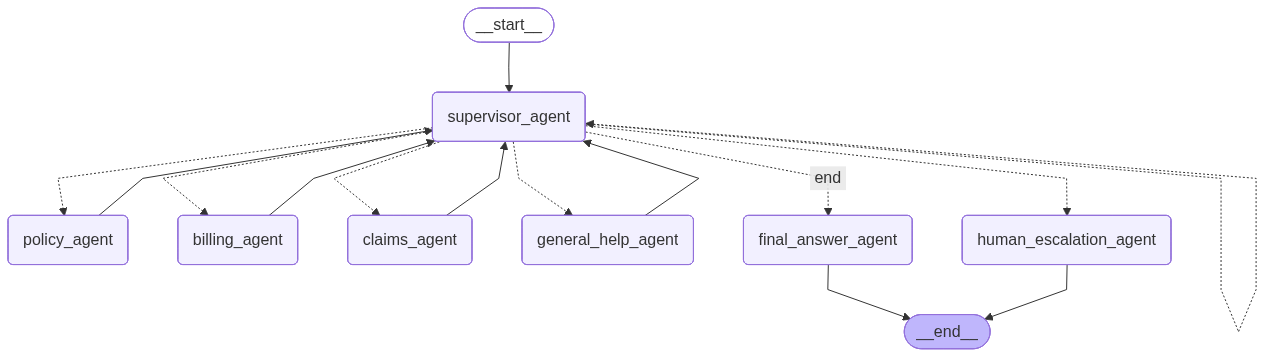

In [0]:
# ── Cell 24: Visualize the Compiled LangGraph (Mermaid PNG or DSL fallback) ─

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # playwright not available in Serverless V5 — print Mermaid DSL instead
    print("Graph visualization (paste into https://mermaid.live):")
    print(app.get_graph().draw_mermaid())

## Section 6 — Multi-Agent System Testing
Test runner utility and 5 scenario tests covering all agent paths, clarification, and multi-turn memory.

In [0]:
# ── Cell 25: Test Runner — run_query() with Lakebase Checkpoint Resume and get_conversation_history() 

import uuid

# Fields that must reset on every new turn regardless of checkpoint
_TURN_RESET_FIELDS = {
    "n_iteration": 0,
    "end_conversation": False,
    "final_answer": "",
    "needs_clarification": False,
    "clarification_question": None,
    "user_clarification": None,
    "next_agent": "supervisor_agent",
    "justification": "",
    "requires_human_escalation": False,
    "escalation_reason": "",
    "messages": [],
}

# Full blank state used only for the FIRST turn of a new thread
_BLANK_STATE: GraphState = {
    **_TURN_RESET_FIELDS,
    "user_input": "",
    "conversation_history": "",
    "user_intent": "",
    "customer_id": "",
    "policy_number": "",
    "claim_id": "",
    "task": "Help the user with their query.",
    "extracted_entities": {},
    "database_lookup_result": {},
    "billing_amount": None,
    "payment_method": None,
    "billing_frequency": None,
    "invoice_date": None,
    "timestamp": None,
}


def run_query(query: str, thread_id: str = None) -> tuple:
    """
    Run a user query through the multi-agent system.

    Args:
        query     : The user's natural language query.
        thread_id : Conversation session ID. Pass the same thread_id across
                    multiple turns to maintain memory. If None, a new session
                    is created automatically.

    Returns:
        (final_state, thread_id)

    Memory behaviour:
        New thread_id   → Blank state. All context fields are empty.
        Same thread_id  → Checkpoint is loaded from Lakebase. Only turn-specific
                          fields reset (iteration, flags, final_answer).
                          Context fields (policy_number, customer_id, claim_id,
                          conversation_history) are carried forward from the
                          checkpoint — no re-asking for already-provided info.
    """
    config = {"configurable": {"thread_id": thread_id or str(uuid.uuid4())}}
    thread_id = config["configurable"]["thread_id"]

    # ── Load checkpoint if this is a follow-up turn ──────────────────────────
    snapshot = app.get_state(config)

    if snapshot.values:
        # Follow-up turn: resume from checkpoint.
        # Carry forward all context fields (policy_number, customer_id, etc.).
        # Only reset turn-specific operational fields.
        prior_history = snapshot.values.get("conversation_history", "")
        state_input: GraphState = {
            **snapshot.values,  # full checkpoint state
            **_TURN_RESET_FIELDS,  # reset turn-specific fields
            "user_input": query,
            "conversation_history": prior_history + f"\nUser: {query}",
        }
        print(f"\n{'='*60}")
        print(f"QUERY     : {query}")
        print(f"THREAD ID : {thread_id}  [RESUMED from Lakebase checkpoint]")
        print(
            f"Context   : policy={snapshot.values.get('policy_number') or 'none'} "
            f"| customer={snapshot.values.get('customer_id') or 'none'}"
        )
        print(f"{'='*60}\n")
    else:
        # First turn: no checkpoint yet — start with a blank state.
        state_input = {
            **_BLANK_STATE,
            "user_input": query,
            "conversation_history": f"User: {query}",
        }
        print(f"\n{'='*60}")
        print(f"QUERY     : {query}")
        print(f"THREAD ID : {thread_id}  [NEW session]")
        print(f"{'='*60}\n")

    try:
        final_state = app.invoke(state_input, config=config)
    except AgentClarificationNeeded as e:
        raise RuntimeError(
            f"\n⚠️  AgentClarificationNeeded was raised during app.invoke().\n"
            f"   This means INSURANCE_AGENT_DEPLOYED=true is set in the notebook environment.\n"
            f"   Unset it with:  del os.environ['INSURANCE_AGENT_DEPLOYED']\n"
            f"   Clarification question was: '{e.question}'"
        ) from e

    print("\n---FINAL RESPONSE---")
    print(final_state.get("final_answer") or "No final answer generated.")
    return final_state, thread_id


def get_conversation_history(thread_id: str) -> None:
    """Print the full checkpoint state stored in Lakebase for a given thread."""
    config = {"configurable": {"thread_id": thread_id}}
    snapshot = app.get_state(config)
    if snapshot.values:
        print(f"Thread         : {thread_id}")
        print(f"Policy number  : {snapshot.values.get('policy_number') or 'none'}")
        print(f"Customer ID    : {snapshot.values.get('customer_id') or 'none'}")
        print(
            f"\nConversation history:\n{snapshot.values.get('conversation_history', '')}"
        )
    else:
        print(f"No checkpoint found for thread_id: {thread_id}")

In [0]:
# ── Cell 26: Test 1 — Billing Query: Supervisor asks_user for policy number, routes to Billing Agent 

# Flow: User → Supervisor → ask_user → Billing Agent → Supervisor → Final Answer

final_state, thread1 = run_query("What is the premium of my auto insurance policy?")
# thread1 is stored — pass it back for follow-up questions in the same session


QUERY     : What is the premium of my auto insurance policy?
THREAD ID : 84352830-3b65-4320-b8ed-b0d0b0cd8a5e  [NEW session]

---SUPERVISOR AGENT---
🔢 Supervisor iteration: 1
🤖 Calling Claude Sonnet 4.6 (Supervisor)...


2026-05-22 07:22:43,715 - __main__ - INFO - 🗣 Asking user: Please provide your policy number or customer ID to look up your premium.


🛠 Supervisor requesting clarification from user
❓ Asking user: Please provide your policy number or customer ID to look up your premium.
---USER INPUT REQUIRED---
Missing: Policy number or customer ID


Please provide your policy number or customer ID to look up your premium.:  POL000066

2026-05-22 07:22:49,205 - __main__ - INFO - ✅ User answered: POL000066


✅ User responded: POL000066
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 2
🔄 Clarification processed — continuing to routing decision
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: billing_agent---
Task: Retrieve the premium details for auto insurance policy number POL000066.
Reason: The user is asking about the premium of their auto insurance policy, which is a billing/payment question. The policy number POL000066 has already been provided in the conversation history, so no additional information is needed. Routing to billing_agent to fetch the premium details.
---BILLING AGENT---


2026-05-22 07:22:55,528 - __main__ - INFO - 🔍 get_billing_info: policy=POL000066, customer=None
2026-05-22 07:22:57,004 - __main__ - INFO - ✅ Billing info found
2026-05-22 07:22:57,005 - __main__ - INFO - 🔍 get_payment_history: POL000066
2026-05-22 07:22:57,896 - __main__ - INFO - ✅ Found 1 payment records


✅ Billing agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 3
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: end---
Task: No further action required.
Reason: The billing_agent has fully resolved the user's question. The premium details for auto insurance policy POL000066 have been provided: $353.80 monthly premium, $650.44 currently due by June 14, 2024, with an active policy status. The conversation is complete.
---FINAL ANSWER AGENT---
✅ Final answer generated

---FINAL RESPONSE---
Your monthly auto insurance premium for policy **POL000066** is **$353.80**, billed on a monthly basis. Your policy is currently active.

Please note that you have an amount of **$650.44** currently due by **June 14, 2024**.

If you have any further questions about your policy or need assistance with a payment, feel free to ask — I'm happy to help! 😊


In [0]:
# ── Cell 27: Test 2 — General FAQ: No policy number needed, routes to General Help Agent via Vector Search 

# Flow: User → Supervisor → General Help Agent (Vector Search) → Supervisor → Final Answer

final_state, thread2 = run_query("In general, what does life insurance cover?")


QUERY     : In general, what does life insurance cover?
THREAD ID : 65db1e5f-8027-450c-b09d-c638f56e774e  [NEW session]

---SUPERVISOR AGENT---
🔢 Supervisor iteration: 1
🤖 Calling Claude Sonnet 4.6 (Supervisor)...


2026-05-22 07:23:58,349 - __main__ - INFO - 🔍 retrieve_faq: 'In general, what does life insurance cover?...'


✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: general_help_agent---
Task: Explain what life insurance generally covers (no policy number needed).
Reason: The user is asking a general FAQ-style question about life insurance coverage. No policy number, customer ID, or claim ID is required. This is a straightforward informational query best handled by the general_help_agent.
---GENERAL HELP AGENT (Vector Search RAG)---
🔍 Querying Databricks Vector Search...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026-05-22 07:23:59,202 - __main__ - INFO - ✅ Retrieved 3 FAQs from Vector Search


📚 Retrieved 3 FAQs
✅ General help agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 2
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: end---
Task: No further action needed.
Reason: The user asked a general question about what life insurance covers, and the general_help_agent provided a comprehensive and complete answer covering what life insurance includes, common exclusions, and special policy types. The question has been fully resolved with no follow-up questions from the user.
---FINAL ANSWER AGENT---
✅ Final answer generated

---FINAL RESPONSE---
# What Does Life Insurance Generally Cover?

Life insurance is designed to provide a **death benefit** to your beneficiaries when you pass away. Here's a simple breakdown:

---

## ✅ What's Typically Covered

- **Natural causes** – illness, disease, old age, and other medical conditions
- **Accidental death** – injuries or unexpected accidents
- **Most causes of death**

In [0]:
# ── Cell 28: Test 3 — Human Escalation: Supervisor routes directly to Human Escalation Agent → END 

# Flow: User → Supervisor → Human Escalation Agent → END

final_state, thread3 = run_query("I want to speak to a human executive.")


QUERY     : I want to speak to a human executive.
THREAD ID : 865d4cfb-2c82-435f-86a2-f30f4dc2a884  [NEW session]

---SUPERVISOR AGENT---
🔢 Supervisor iteration: 1
🤖 Calling Claude Sonnet 4.6 (Supervisor)...


2026-05-22 07:24:31,982 - __main__ - INFO - 🔍 retrieve_faq: 'I want to speak to a human executive....'


❌ Supervisor JSON parse failed: Expecting value: line 1 column 1 (char 0)
   Raw response: Based on my analysis of the conversation, the user has explicitly requested to speak to a human executive. This is a clear escalation request that should be routed directly to the human escalation agent.

```json
{
  "next_agent": "human_escalation_agent",
  "task": "User has explicitly requested to speak with a human executive. No policy number or customer ID provided.",
  "justification": "The u
---SUPERVISOR DECISION: general_help_agent---
Task: Assist the user with their query.
Reason: 
---GENERAL HELP AGENT (Vector Search RAG)---
🔍 Querying Databricks Vector Search...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026-05-22 07:24:32,844 - __main__ - INFO - ✅ Retrieved 3 FAQs from Vector Search


📚 Retrieved 3 FAQs
✅ General help agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 2
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: human_escalation_agent---
Task: User explicitly requested to speak with a human executive. Route to human escalation for live agent connection.
Reason: The user has clearly and explicitly requested to speak with a human executive. Despite the general_help_agent providing options, the user's core intent remains to be connected to a human representative. This warrants routing to the human_escalation_agent to fulfill that request appropriately.
---HUMAN ESCALATION AGENT---
🚨 Escalated to human

---FINAL RESPONSE---
# Connecting You to a Human Executive 🤝

---

Thank you so much for your patience, and I completely understand your request to speak with a human executive.

**You are being connected to a live human representative right now.**

---

## What Happens Next:

- ✅ A **human execut

In [0]:
# ── Cell 29: Test 4 — Policy Details: Supervisor asks_user for policy number, routes to Policy Agent 

# Flow: User → Supervisor → ask_user → Policy Agent → Supervisor → Final Answer

final_state, thread4 = run_query(
    "What type of policy do I have and when does it expire?"
)


QUERY     : What type of policy do I have and when does it expire?
THREAD ID : fb82b0ae-e50f-4266-b0a5-d35929be06be  [NEW session]

---SUPERVISOR AGENT---
🔢 Supervisor iteration: 1
🤖 Calling Claude Sonnet 4.6 (Supervisor)...


2026-05-22 07:25:05,166 - __main__ - INFO - 🗣 Asking user: Could you please provide your policy number?


🛠 Supervisor requesting clarification from user
❓ Asking user: Could you please provide your policy number?
---USER INPUT REQUIRED---
Missing: Policy number required to retrieve policy type and expiration details


Could you please provide your policy number?:  POL000066

2026-05-22 07:25:10,556 - __main__ - INFO - ✅ User answered: POL000066


✅ User responded: POL000066
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 2
🔄 Clarification processed — continuing to routing decision
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: policy_agent---
Task: Retrieve policy type and expiration date for policy number POL000066.
Reason: The user is asking about their policy type and expiration date. The policy number POL000066 has already been provided in the conversation history. No additional information is needed. This is a policy details inquiry, so routing to policy_agent is appropriate.
---POLICY AGENT---


2026-05-22 07:25:15,373 - __main__ - INFO - 🔍 get_policy_details: POL000066
2026-05-22 07:25:16,502 - __main__ - INFO - ✅ Policy found: POL000066


✅ Policy agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 3
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: end---
Task: No further action required.
Reason: The user's question about policy type and expiration date has been fully answered by the policy_agent. The policy details for POL000066 were successfully retrieved — it is a Life Insurance policy that is currently Active, with a note explaining that no specific expiration date is available in the record (common for life insurance policies). The response also provided a recommendation for obtaining the exact maturity date. The conversation is fully resolved.
---FINAL ANSWER AGENT---
✅ Final answer generated

---FINAL RESPONSE---
Hi Ava! Here's a quick summary of your policy details:

- **Policy Type:** Life Insurance
- **Policy Number:** POL000066
- **Status:** Active ✅
- **Start Date:** February 15, 2023

Regarding the **expiration date**, your policy record do

In [0]:
# ── Cell 30: Test 4b — Multi-Turn Follow-Up: Resumes thread4 from Lakebase checkpoint, no re-asking for policy number 

# Passes thread4 so the graph resumes from the Lakebase checkpoint.
# The supervisor already knows the policy number from the prior turn.

final_state, thread4 = run_query(
    "What is the premium for that policy?", thread_id=thread4
)


QUERY     : What is the premium for that policy?
THREAD ID : fb82b0ae-e50f-4266-b0a5-d35929be06be  [RESUMED from Lakebase checkpoint]
Context   : policy=none | customer=none

---SUPERVISOR AGENT---
🔢 Supervisor iteration: 1
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: billing_agent---
Task: Retrieve the premium amount for policy number POL000066 (Life Insurance) for customer Ava Torres.
Reason: The user is asking about the premium for their policy. The policy number POL000066 is already known from the conversation history. This is a billing/payment question, so it should be routed to the billing_agent. Note: The premium was already mentioned as $353.80/month in the previous policy_agent response, but routing to billing_agent for a complete and authoritative answer.
---BILLING AGENT---


2026-05-22 07:28:03,352 - __main__ - INFO - 🔍 get_billing_info: policy=POL000066, customer=Ava Torres
2026-05-22 07:28:04,190 - __main__ - INFO - ✅ Billing info found


✅ Billing agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 2
🤖 Calling Claude Sonnet 4.6 (Supervisor)...


2026-05-22 07:28:09,392 - __main__ - INFO - 🔍 retrieve_faq: 'What is the premium for that policy?...'


❌ Supervisor JSON parse failed: Extra data: line 6 column 1 (char 300)
   Raw response: ```json
{
  "next_agent": "end",
  "task": "No further action required.",
  "justification": "The billing agent has already fully answered the user's question about the premium for policy POL000066. The premium is $353.80 per month, which directly resolves the user's query. No further routing is needed."
}
```

---

Your question has already been answered! Here's a quick recap:

- **Policy Number:
---SUPERVISOR DECISION: general_help_agent---
Task: Assist the user with their query.
Reason: 
---GENERAL HELP AGENT (Vector Search RAG)---
🔍 Querying Databricks Vector Search...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026-05-22 07:28:10,490 - __main__ - INFO - ✅ Retrieved 3 FAQs from Vector Search


📚 Retrieved 3 FAQs
✅ General help agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 3
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: end---
Task: No further action required.
Reason: The user's question about the premium for policy POL000066 has been fully answered. The billing agent confirmed the premium is $353.80/month, and this was clearly communicated to Ava. There are no pending questions or unresolved issues.
---FINAL ANSWER AGENT---
✅ Final answer generated

---FINAL RESPONSE---
Here are the premium details for your Life Insurance policy (POL000066):

- **Premium Amount:** $353.80
- **Billing Frequency:** Monthly

Your monthly premium is **$353.80**, billed on a monthly basis.

If you have any other questions, feel free to ask — I'm happy to help! 😊


In [0]:
# ── Cell 31: Test 4c — Inspect Lakebase Checkpoint: Print full GraphState stored for thread4 

get_conversation_history(thread4)

Thread         : fb82b0ae-e50f-4266-b0a5-d35929be06be
Policy number  : none
Customer ID    : none

Conversation history:
User: What type of policy do I have and when does it expire?
Assistant: Could you please provide your policy number?
User: POL000066
Assistant: Could you please provide your policy number?
User: POL000066
Assistant: Routing to policy_agent for: Retrieve policy type and expiration date for policy number POL000066.
Policy Agent: I have successfully retrieved the policy details for **POL000066**. Here is a summary:

---

### 📋 Policy Details for POL000066

| Field | Details |
|---|---|
| **Policy Holder** | Ava Torres |
| **Policy Number** | POL000066 |
| **Policy Type** | **Life Insurance** |
| **Status** | ✅ Active |
| **Start Date** | February 15, 2023 |
| **Premium Amount** | $353.80 / month |
| **Billing Frequency** | Monthly |

---

> ⚠️ **Note on Expiration Date:** The retrieved policy record does not include a specific expiration date for this life insurance pol

In [0]:
# ── Cell 32: Test 5 — Claims Status: Supervisor asks_user for claim/policy ID, routes to Claims Agent 

# Flow: User → Supervisor → ask_user → Claims Agent → Supervisor → Final Answer

final_state, thread5 = run_query("What is the status of my recent claim?")


QUERY     : What is the status of my recent claim?
THREAD ID : 87f990c9-856c-4bd6-947b-3aedb3a77b22  [NEW session]

---SUPERVISOR AGENT---
🔢 Supervisor iteration: 1
🤖 Calling Claude Sonnet 4.6 (Supervisor)...


2026-05-22 07:28:44,318 - __main__ - INFO - 🗣 Asking user: Please provide your policy number or claim ID to look up your claim status.


🛠 Supervisor requesting clarification from user
❓ Asking user: Please provide your policy number or claim ID to look up your claim status.
---USER INPUT REQUIRED---
Missing: Policy number or claim ID


Please provide your policy number or claim ID to look up your claim status.:  POL000066

2026-05-22 07:28:51,152 - __main__ - INFO - ✅ User answered: POL000066


✅ User responded: POL000066
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 2
🔄 Clarification processed — continuing to routing decision
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: claims_agent---
Task: Look up the status of the most recent claim for policy number POL000066.
Reason: The user is asking about their claim status and has already provided their policy number (POL000066) twice. No additional information is needed. This is a claims-related request, so it should be routed to the claims_agent.
---CLAIMS AGENT---


2026-05-22 07:28:56,171 - __main__ - INFO - 🔍 get_claim_status: claim_id=None, policy=POL000066
2026-05-22 07:28:57,085 - __main__ - INFO - ✅ Found 1 claim(s)


✅ Claims agent completed
---SUPERVISOR AGENT---
🔢 Supervisor iteration: 3
🤖 Calling Claude Sonnet 4.6 (Supervisor)...
✅ Supervisor JSON parsed successfully
---SUPERVISOR DECISION: end---
Task: No further action required.
Reason: The user's question about their recent claim status has been fully resolved. The claims_agent successfully retrieved and displayed the details for claim CLM000202 under policy POL000066, including the claim status (Active), incident type (Collision), estimated loss ($2,436.56), and next steps. There are no pending questions or unresolved issues.
---FINAL ANSWER AGENT---
✅ Final answer generated

---FINAL RESPONSE---
Here's the status of your most recent claim:

---

### 📋 Your Recent Claim Status

| Field | Details |
|-------|---------|
| **Claim ID** | CLM000202 |
| **Claim Date** | January 24, 2024 |
| **Incident Type** | Collision |
| **Estimated Loss** | $2,436.56 |
| **Status** | ✅ **Active** |

---

Your claim is currently **active** and being processed b

## Section 7 — Vision Pipeline (Standalone)
Multimodal claim processing using Claude Sonnet 4.6 vision.
Processes car damage images, driving license OCR, claim form OCR,
cross-document consistency checks, and Vector Search coverage lookup.

> **Note**: This section is independent of the main LangGraph agent graph.
> Run Cells 1–14 and Cell 15 (LLM client) before running this section.
> Test images must be present in `VOLUME_PATH/test_images/`.

In [0]:
# ── Cell V1: Vision Pipeline — Set Image Paths in UC Volume ─────────────────

BASE_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME_NAME}/test_images"
CAR_IMAGE_PATH = f"{BASE_PATH}/sample_car_damage.png"
DL_IMAGE_PATH = f"{BASE_PATH}/sample_driving_license.png"
FORM_IMAGE_PATH = f"{BASE_PATH}/sample_claim_form.png"

print(f"✅ Image paths set")
print(f"   Car damage   : {CAR_IMAGE_PATH}")
print(f"   Driving lic  : {DL_IMAGE_PATH}")
print(f"   Claim form   : {FORM_IMAGE_PATH}")

2026-05-22 07:30:31,839 - py4j.clientserver - INFO - Python Server ready to receive messages
2026-05-22 07:30:31,840 - py4j.clientserver - INFO - Received command c on object id p0


✅ Image paths set
   Car damage   : /Volumes/main/insurance_support/insurance_support_vol/test_images/sample_car_damage.png
   Driving lic  : /Volumes/main/insurance_support/insurance_support_vol/test_images/sample_driving_license.png
   Claim form   : /Volumes/main/insurance_support/insurance_support_vol/test_images/sample_claim_form.png


In [0]:
# ── Cell V2: Vision Helpers — encode_image() Base64 Encoder and vision_call() LLM Wrapper 

import base64
import re
import json
from pathlib import Path


def encode_image(path: str) -> tuple:
    """Read an image file and return (base64_string, media_type)."""
    suffix = Path(path).suffix.lower()
    media_type = {
        ".png": "image/png",
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".gif": "image/gif",
        ".webp": "image/webp",
    }.get(suffix, "image/png")

    with open(path, "rb") as f:
        b64 = base64.standard_b64encode(f.read()).decode("utf-8")

    return b64, media_type


def vision_call(image_path: str, system_prompt: str, user_prompt: str) -> str:
    """
    Send a single image to Claude Sonnet 4.6 via deploy_client.
    Uses OpenAI-compatible image_url format with a base64 data URL.
    Returns the raw text response.
    """
    b64_data, media_type = encode_image(image_path)

    # Build data URL — required by Databricks Claude endpoint
    data_url = f"data:{media_type};base64,{b64_data}"

    response = deploy_client.predict(
        endpoint=LLM_ENDPOINT,
        inputs={
            "messages": [
                {"role": "system", "content": system_prompt},
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",  # OpenAI-compatible
                            "image_url": {"url": data_url},  # base64 data URL
                        },
                        {"type": "text", "text": user_prompt},
                    ],
                },
            ],
            "max_tokens": 1024,
        },
    )
    return response["choices"][0]["message"]["content"]


def parse_llm_json(raw: str) -> dict:
    """Strip markdown fences from LLM response and parse JSON."""
    cleaned = re.sub(r"^```(?:json)?\s*\n?", "", raw.strip())
    cleaned = re.sub(r"\n?```\s*$", "", cleaned)
    return json.loads(cleaned)


print("✅ Vision helper functions defined")

✅ Vision helper functions defined


In [0]:
# ── Cell V3: Vision — Extract Structured Car Damage Details from Image (JSON output) 

SYSTEM_CAR = """You are a vehicle damage assessment specialist.
Analyze the car image and extract structured information.
Respond ONLY with a valid JSON object — no markdown, no explanation."""

USER_CAR = """Analyze this vehicle damage photo and return a JSON object
with exactly these fields:
{
  "vehicle_make": "manufacturer name",
  "vehicle_model": "model name if visible",
  "vehicle_color": "color of the vehicle",
  "vehicle_type": "sedan / SUV / truck / etc",
  "damage_location": "which part of the vehicle is damaged",
  "damage_severity": "minor / moderate / severe",
  "damage_description": "detailed description of visible damage",
  "additional_observations": "any other relevant observations"
}"""

print("Analyzing car damage image...")
car_data = parse_llm_json(vision_call(CAR_IMAGE_PATH, SYSTEM_CAR, USER_CAR))

print("\n📋 Car Damage Extraction Result:")
for k, v in car_data.items():
    print(f"   {k:<28} : {v}")

Analyzing car damage image...

📋 Car Damage Extraction Result:
   vehicle_make                 : Honda
   vehicle_model                : Civic
   vehicle_color                : Blue
   vehicle_type                 : Sedan
   damage_location              : Front left / driver's side front quarter panel, left fender, left front door, and left headlight assembly
   damage_severity              : Severe
   damage_description           : Significant impact damage concentrated on the front-left corner of the vehicle. The left fender is heavily crumpled and deformed. The front left door shows intrusion and creasing near the A-pillar junction. The left headlight assembly appears damaged and misaligned. The front bumper on the left side shows cracking and displacement. The hood appears slightly raised/misaligned on the left side, suggesting possible frame or strut tower damage underneath. Metal is buckled and folded inward indicating a high-energy lateral or front-corner impact.
   additional_o

In [0]:
# ── Cell V4: Vision — Driving License OCR: Extract DL number, Name, DOB, Expiry, Validity 

SYSTEM_DL = """You are a document OCR specialist.
Extract all text fields from the driving license or ID card image.
Respond ONLY with a valid JSON object — no markdown, no explanation."""

USER_DL = """Extract all information from this driving license / ID card image
and return a JSON object with exactly these fields:
{
  "dl_number": "license or ID number",
  "full_name": "full name on the document",
  "date_of_birth": "DOB in DD-MON-YYYY format",
  "address": "full address",
  "license_class": "license class or type if present",
  "issue_date": "issue date in DD-MON-YYYY format",
  "expiry_date": "expiry date in DD-MON-YYYY format",
  "issuing_state": "state or authority that issued the document",
  "is_valid": true or false based on expiry date vs today (2026-05-14)
}"""

print("Extracting driving license details...")
dl_data = parse_llm_json(vision_call(DL_IMAGE_PATH, SYSTEM_DL, USER_DL))

print("\n📋 Driving License Extraction Result:")
for k, v in dl_data.items():
    print(f"   {k:<28} : {v}")

Extracting driving license details...

📋 Driving License Extraction Result:
   dl_number                    : DL-CA-4872910
   full_name                    : Emma Rodriguez
   date_of_birth                : 17-FEB-1990
   address                      : 142 Maple Drive, Sacramento, CA 95814
   license_class                : C
   issue_date                   : 12-MAR-2021
   expiry_date                  : 12-MAR-2027
   issuing_state                : Sample State (California)
   is_valid                     : True


In [0]:
# ── Cell V5: Vision — Claim Form OCR: Extract All Fields from Motor Insurance Claim Form 

SYSTEM_FORM = """You are an insurance claims document specialist.
Extract all data from the claim form image with high accuracy.
Respond ONLY with a valid JSON object — no markdown, no explanation."""

USER_FORM = """Extract all information from this motor insurance claim form
and return a JSON object with exactly these fields:
{
  "policy_number": "policy number",
  "policy_type": "type of insurance policy",
  "insured_name": "name of the insured person",
  "policy_start_date": "policy start date",
  "policy_end_date": "policy end date",
  "incident_date": "date of incident",
  "incident_time": "time of incident",
  "incident_location": "location of incident",
  "incident_type": "type of incident",
  "police_report_number": "police report number if available",
  "vehicle_make": "vehicle make",
  "vehicle_model": "vehicle model",
  "vehicle_year": "vehicle year",
  "vehicle_color": "vehicle color",
  "vehicle_vin": "vehicle VIN number",
  "license_plate": "license plate number",
  "dl_number": "driving license number from form",
  "dl_holder_name": "name on driving license as stated in form",
  "dl_expiry": "driving license expiry date",
  "damage_description": "detailed damage description from claimant",
  "estimated_loss": "claimed loss amount as a number",
  "claim_reference": "claim reference number if present"
}"""

print("Extracting claim form data...")
form_data = parse_llm_json(vision_call(FORM_IMAGE_PATH, SYSTEM_FORM, USER_FORM))

print("\n📋 Claim Form Extraction Result:")
for k, v in form_data.items():
    print(f"   {k:<28} : {v}")

Extracting claim form data...

📋 Claim Form Extraction Result:
   policy_number                : POL000004
   policy_type                  : Auto Insurance
   insured_name                 : Emma Rodriguez
   policy_start_date            : December 10, 2023
   policy_end_date              : December 9, 2030
   incident_date                : May 3, 2026
   incident_time                : 2:35 PM
   incident_location            : Highway 101, San Jose, CA
   incident_type                : Collision
   police_report_number         : SJPD-2026-04821
   vehicle_make                 : Honda
   vehicle_model                : Civic
   vehicle_year                 : 2020
   vehicle_color                : Blue
   vehicle_vin                  : VIN76195236404115382
   license_plate                : 7ABC123 California
   dl_number                    : DL-CA-4872910
   dl_holder_name               : Emma Rodriguez
   dl_expiry                    : March 12, 2027
   damage_description           : Nort

In [0]:
# ── Cell V6: Vision — Cross-Document Consistency Checks (car vs form, DL vs form, policy validity at incident date) 

from datetime import datetime

print("Running consistency & authenticity checks...\n")
results = {}


def parse_date_flexible(date_str: str):
    """
    Parse dates in any common format Claude might return.
    Handles all variants seen in practice across different document types.
    """
    formats = [
        "%d-%b-%Y",  # 09-DEC-2025  or  09-Dec-2025
        "%d-%B-%Y",  # 09-December-2025
        "%Y-%m-%d",  # 2025-12-09
        "%d/%m/%Y",  # 09/12/2025
        "%m/%d/%Y",  # 12/09/2025
        "%B %d, %Y",  # December 9, 2025   ← most common Claude output
        "%b %d, %Y",  # Dec 9, 2025
        "%d %B %Y",  # 9 December 2025
        "%d %b %Y",  # 9 Dec 2025
        "%B %d %Y",  # December 9 2025    (no comma)
    ]
    cleaned = date_str.strip().replace("  ", " ")
    for fmt in formats:
        try:
            return datetime.strptime(cleaned, fmt)
        except ValueError:
            continue

    try:
        from dateutil import parser as dateutil_parser

        return dateutil_parser.parse(cleaned)
    except Exception:
        pass
    return None


def fuzzy_match(a: str, b: str) -> bool:
    """Check if two strings match after lowercasing and stripping punctuation."""
    import re

    clean = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())
    a_clean, b_clean = clean(a), clean(b)
    return a_clean == b_clean or a_clean in b_clean or b_clean in a_clean


# ── Check 1: Car Image vs Claim Form (vehicle details) ────────────────────────

print("📌 Check 1 — Car Image vs Claim Form:")
img_vs_form = {
    "vehicle_color_match": (
        car_data.get("vehicle_color", ""),
        form_data.get("vehicle_color", ""),
    ),
    "vehicle_make_match": (
        car_data.get("vehicle_make", ""),
        form_data.get("vehicle_make", ""),
    ),
    "vehicle_model_match": (
        car_data.get("vehicle_model", ""),
        form_data.get("vehicle_model", ""),
    ),
}
for check, (val_a, val_b) in img_vs_form.items():
    match = fuzzy_match(val_a, val_b)
    results[check] = match
    status = "✅ PASS" if match else "❌ FAIL"
    print(f"   {status}  {check}: image='{val_a}' | form='{val_b}'")


# ── Check 2: Driving License vs Claim Form ─────────────────────────────────────

print("\n📌 Check 2 — Driving License vs Claim Form:")
dl_vs_form = {
    "dl_number_match": (
        dl_data.get("dl_number", ""),
        form_data.get("dl_number", ""),
    ),
    "customer_name_match": (
        dl_data.get("full_name", ""),
        form_data.get("dl_holder_name", ""),
    ),
}
for check, (val_a, val_b) in dl_vs_form.items():
    match = fuzzy_match(val_a, val_b)
    results[check] = match
    status = "✅ PASS" if match else "❌ FAIL"
    print(f"   {status}  {check}: dl='{val_a}' | form='{val_b}'")


# ── Check 3: Policy end date must be >= incident date ─────────────────────────

print("\n📌 Check 3 — Policy validity at incident date:")
policy_end_str = form_data.get("policy_end_date", "")
incident_dt_str = form_data.get("incident_date", "")
policy_end = parse_date_flexible(policy_end_str)
incident_dt = parse_date_flexible(incident_dt_str)

if policy_end and incident_dt:
    valid = policy_end >= incident_dt
    results["policy_valid_at_incident"] = valid
    status = "✅ PASS" if valid else "❌ FAIL"
    print(
        f"   {status}  policy_end={policy_end.date()} >= incident={incident_dt.date()}: {valid}"
    )
else:
    print(f"   ⚠️  Could not parse dates:")
    print(f"      policy_end  : '{policy_end_str}' → {policy_end}")
    print(f"      incident    : '{incident_dt_str}' → {incident_dt}")
    results["policy_valid_at_incident"] = False


# ── Overall result ─────────────────────────────────────────────────────────────

all_passed = all(results.values())
print(f"\n{'='*55}")
print(
    f"OVERALL RESULT : {'✅ ALL CHECKS PASSED' if all_passed else '❌ ONE OR MORE CHECKS FAILED'}"
)
print(f"{'='*55}")
for k, v in results.items():
    print(f"   {'✅ PASS' if v else '❌ FAIL'}  {k}")

Running consistency & authenticity checks...

📌 Check 1 — Car Image vs Claim Form:
   ✅ PASS  vehicle_color_match: image='Blue' | form='Blue'
   ✅ PASS  vehicle_make_match: image='Honda' | form='Honda'
   ✅ PASS  vehicle_model_match: image='Civic' | form='Civic'

📌 Check 2 — Driving License vs Claim Form:
   ✅ PASS  dl_number_match: dl='DL-CA-4872910' | form='DL-CA-4872910'
   ✅ PASS  customer_name_match: dl='Emma Rodriguez' | form='Emma Rodriguez'

📌 Check 3 — Policy validity at incident date:
   ✅ PASS  policy_end=2030-12-09 >= incident=2026-05-03: True

OVERALL RESULT : ✅ ALL CHECKS PASSED
   ✅ PASS  vehicle_color_match
   ✅ PASS  vehicle_make_match
   ✅ PASS  vehicle_model_match
   ✅ PASS  dl_number_match
   ✅ PASS  customer_name_match
   ✅ PASS  policy_valid_at_incident


In [0]:
# ── Cell V7: Vision — Vector Search Coverage Lookup (only executes if all consistency checks pass) 

if not all_passed:
    print("⛔ Checks failed — claim rejected.")
    print("   Next step in production: send rejection email to customer.")
else:
    print("✅ All checks passed — querying Vector Search for coverage...\n")

    idx = vsc.get_index(endpoint_name=VS_ENDPOINT_NAME, index_name=VS_INDEX_NAME)

    # Build semantic query from extracted damage and policy context
    coverage_query = (
        f"{car_data.get('damage_description', '')} "
        f"{car_data.get('damage_location', '')} "
        f"auto insurance collision coverage "
        f"{form_data.get('policy_type', '')}"
    )

    response = idx.similarity_search(
        query_text=coverage_query,
        columns=["id", "question", "answer"],
        num_results=3,
    )
    col_names = [c["name"] for c in response["manifest"]["columns"]]
    rows = response["result"].get("data_array", [])

    if rows:
        print(f"📚 Found {len(rows)} relevant coverage FAQ(s):\n")
        for row in rows:
            record = dict(zip(col_names, row))
            print(f"  Q: {str(record.get('question', ''))[:80]}...")
            print(f"  A: {str(record.get('answer', ''))[:120]}...")
            print()
        print("✅ Coverage found — route to Claim Handler in production.")
    else:
        print("⚠️  No relevant coverage found.")
        print("   Next step in production: send rejection email to customer.")

✅ All checks passed — querying Vector Search for coverage...

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
📚 Found 3 relevant coverage FAQ(s):

  Q: Does Insurance Cover A Tree Parked In The Street Crushed By A Falling Tree? ...
  A: Falling objects whether they are trees , airplane parts , stones from a gravel truck or something else are covered under...

  Q: Will Insurance Cover If My Car Is Broken Into? ...
  A: Yes , there is coverage under the comprehensive portion of your auto policy . In order to receive payment the amount los...

  Q: What Does PIP Stand For In Auto Insurance? ...
  A: PIP stands for Personal Injury Protection . PIP covers medical expenses from an auto accident . This is a no-fault cover...

✅ Coverage found — route to Claim Handler in production.


In [0]:
# ── Cell V8: Vision — Full Extraction and Check Summary (car damage, DL, claim form, consistency results, outcome) 

print("=" * 60)
print("CLAIM PROCESSING VISION TEST — FULL SUMMARY")
print("=" * 60)

print("\n🚗 CAR DAMAGE:")
for k, v in car_data.items():
    print(f"   {k:<28} : {v}")

print("\n🪪 DRIVING LICENSE:")
for k, v in dl_data.items():
    print(f"   {k:<28} : {v}")

print("\n📄 CLAIM FORM:")
for k, v in form_data.items():
    print(f"   {k:<28} : {v}")

print("\n✅ CONSISTENCY CHECKS:")
for k, v in results.items():
    print(f"   {'PASS' if v else 'FAIL'}  {k}")

print("\n" + "=" * 60)
status_msg = (
    "READY FOR CLAIM HANDLER" if all_passed else "CLAIM REJECTED — CHECKS FAILED"
)
print(f"OUTCOME : {status_msg}")
print("=" * 60)

CLAIM PROCESSING VISION TEST — FULL SUMMARY

🚗 CAR DAMAGE:
   vehicle_make                 : Honda
   vehicle_model                : Civic
   vehicle_color                : Blue
   vehicle_type                 : Sedan
   damage_location              : Front left / driver's side front quarter panel, left fender, left front door, and left headlight assembly
   damage_severity              : Severe
   damage_description           : Significant impact damage concentrated on the front-left corner of the vehicle. The left fender is heavily crumpled and deformed. The front left door shows intrusion and creasing near the A-pillar junction. The left headlight assembly appears damaged and misaligned. The front bumper on the left side shows cracking and displacement. The hood appears slightly raised/misaligned on the left side, suggesting possible frame or strut tower damage underneath. Metal is buckled and folded inward indicating a high-energy lateral or front-corner impact.
   additional_obser

## Section 8 — Model Deployment
Package `InsuranceAgentModel` as a self-contained MLflow PyFunc, register to Unity Catalog,
and deploy via `agents.deploy()` to a Databricks Model Serving endpoint.

**Run order**: D1 → D2 → D3 → D4 → D5 → D6 → D7 → D8 → D9

> **Key design**: The deployed model is fully self-contained — no LangGraph, no Spark.
> It uses the SQL REST API with a long-lived PAT for all database queries.

In [0]:
# ── Cell D1: Verify databricks-agents Package is Available in the Cluster Environment 

import importlib.metadata

print(f"databricks-agents version : {importlib.metadata.version('databricks-agents')}")
print("✅ Ready to proceed with deployment cells")

databricks-agents version : 1.10.2
✅ Ready to proceed with deployment cells


In [0]:
# ── Cell D2: Deployment-Aware ask_user() — Dual Execution: input() in notebook, AgentClarificationNeeded when deployed 

#
# PURPOSE: Overwrites ask_user() in this notebook kernel so that:
#   - Notebook mode  (INSURANCE_AGENT_DEPLOYED not set) → calls input() as before
#   - Env-var test   (INSURANCE_AGENT_DEPLOYED=true)    → raises AgentClarificationNeeded
#
# SCOPE: This cell affects only the NOTEBOOK kernel.
#        The deployed model (D3 / insurance_agent_model.py) embeds its own
#        _ask_user() directly inside InsuranceAgentModel — this cell does NOT
#        affect the deployed endpoint.
#
# ⚠️  IMPORTANT: run_query() catches AgentClarificationNeeded (see fix below).
#    If INSURANCE_AGENT_DEPLOYED is NOT set (default), behaviour is identical
#    to original Cell 15 — input() is called as usual.
# ─────────────────────────────────────────────────────────────────────────────

import os  # explicit import — do not rely on ambient notebook state


class AgentClarificationNeeded(Exception):
    """
    Raised by ask_user() when running as a Model Serving endpoint.
    In notebook mode this exception is caught by run_query() and re-raised
    as a RuntimeError with a clear message so the cause is visible.
    """

    def __init__(self, question: str):
        self.question = question
        super().__init__(question)


def ask_user(question: str, missing_info: str = "") -> Dict[str, Any]:
    """Ask the user for missing information."""

    if os.environ.get("INSURANCE_AGENT_DEPLOYED") == "true":
        # Deployed mode: signal the API layer via exception.
        # predict() in InsuranceAgentModel catches this and returns the
        # question as an assistant message.  No stdin is ever used.
        raise AgentClarificationNeeded(question)

    # Notebook / interactive mode: call input() exactly as original Cell 15
    logger.info(f"🗣 Asking user: {question}")
    if missing_info:
        print(f"---USER INPUT REQUIRED---\nMissing: {missing_info}")
    else:
        print("---USER INPUT REQUIRED---")
    answer = input(f"{question}: ")
    logger.info(f"✅ User answered: {answer}")
    return {"context": answer, "source": "User Input"}


print("✅ Cell D1b: deployment-aware ask_user defined")
print(
    f"   INSURANCE_AGENT_DEPLOYED = {os.environ.get('INSURANCE_AGENT_DEPLOYED', 'not set')}"
)
print("   Notebook mode: input() | Deployed mode: raises AgentClarificationNeeded")

✅ Cell D1b: deployment-aware ask_user defined
   INSURANCE_AGENT_DEPLOYED = not set
   Notebook mode: input() | Deployed mode: raises AgentClarificationNeeded


In [0]:
# ── Cell D3: Configure MLflow Experiment and Unity Catalog Model Name ───────

import mlflow

_current_user = w.current_user.me().user_name
UC_MODEL_NAME = f"{CATALOG}.{SCHEMA}.insurance_support_agent"

EXPERIMENT_FOLDER = (
    f"/Workspace/Users/{_current_user}"
    f"/Multi-agent System for Insurance Customer Care"
)
MLFLOW_EXPERIMENT = f"{EXPERIMENT_FOLDER}/insurance_support_multi_agent"

# ── Create parent folder if it doesn't exist ──────────────────────────────────
try:
    w.workspace.mkdirs(path=EXPERIMENT_FOLDER)
    print(f"✅ Workspace folder ready: {EXPERIMENT_FOLDER}")
except Exception as e:
    print(f"ℹ️  Folder already exists or skipped: {e}")

# ── Set experiment (creates it if missing, now that parent exists) ─────────────
mlflow.set_experiment(MLFLOW_EXPERIMENT)
mlflow.set_registry_uri("databricks-uc")

print(f"✅ MLflow configured")
print(f"   Current user : {_current_user}")
print(f"   Experiment   : {MLFLOW_EXPERIMENT}")
print(f"   Model name   : {UC_MODEL_NAME}")

2026/05/22 07:33:11 INFO mlflow.tracking.fluent: Experiment with name '/Workspace/Users/[REDACTED]/Multi-agent System for Insurance Customer Care/insurance_support_multi_agent' does not exist. Creating a new experiment.


✅ Workspace folder ready: /Workspace/Users/[REDACTED]/Multi-agent System for Insurance Customer Care
✅ MLflow configured
   Current user : [REDACTED]
   Experiment   : /Workspace/Users/[REDACTED]/Multi-agent System for Insurance Customer Care/insurance_support_multi_agent
   Model name   : main.insurance_support.insurance_support_agent


In [0]:
# ── Cell D4: Write InsuranceAgentModel to /tmp — Self-Contained PyFunc with SQL REST API, no Spark or LangGraph 

import ast

AGENT_FILE = "/tmp/insurance_agent_model.py"

agent_code = '''import mlflow
import os
import re
import json
import time
import logging
import requests
import pandas as pd
from typing import Dict, List, Any, Optional
from mlflow.pyfunc import PythonModel
from mlflow.deployments import get_deploy_client

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)

LLM_ENDPOINT      = "databricks-claude-sonnet-4-6"
CATALOG           = "main"
SCHEMA            = "insurance_support"
FULL_SCHEMA       = CATALOG + "." + SCHEMA
VS_ENDPOINT_NAME  = "insurance_vs_endpoint"
VS_INDEX_NAME     = FULL_SCHEMA + ".insurance_faq_vs_index"
MAX_ROUTING_ITERS = 5


class AgentClarificationNeeded(Exception):
    def __init__(self, question: str):
        self.question = question
        super().__init__(question)


SUPERVISOR_PROMPT = """
You are the SUPERVISOR AGENT managing a team of insurance support specialists.

Your role:
1. Review the full conversation history to understand the current request.
2. Identify user intent and any already-provided context (policy number, customer ID, claim ID).
3. Route to the appropriate specialist agent.
4. End the conversation when the task is fully resolved.

AVAILABLE INFORMATION:
- Conversation History: {conversation_history}

CRITICAL RULES:
- If policy number is already available, DO NOT ask for it again.
- If customer ID is already available, DO NOT ask for it again.
- Only use ask_user tool if ESSENTIAL information is missing.
- Check conversation history carefully before requesting clarification.

SPECIALIST AGENTS:
- policy_agent       -> policy details, coverage, endorsements, auto policy specifics
- billing_agent      -> billing, payments, premium questions
- claims_agent       -> claim filing, tracking, settlements
- general_help_agent -> general insurance questions (no policy number needed)
- human_escalation_agent -> complex or sensitive cases

CLARIFICATION GUIDELINES:
1. Keep questions concise (<=15 words).
2. Ask only for ESSENTIAL missing info.

EVALUATION INSTRUCTIONS:
- If the specialist\'s answer fully resolves the question -> route to \'end\'.
- If more information is needed -> use ask_user or route again.

DECISION GUIDELINES:
1. Policy/coverage questions -> policy_agent
2. Billing/payment questions -> billing_agent
3. Claims questions         -> claims_agent
4. General FAQ questions    -> general_help_agent
5. Explicit human request   -> human_escalation_agent
6. Fully answered           -> end

TASK GENERATION GUIDELINES:
- Summarize the user\'s request concisely.
- Include policy number, customer ID, claim ID in the task if known.

Respond ONLY in JSON:
{{
  "next_agent": "<agent_name or \'end\'>",
  "task": "<concise task description>",
  "justification": "<why this decision>"
}}
"""

POLICY_AGENT_PROMPT = """
You are a **Policy Specialist Agent** for an insurance company.

Assigned Task: {task}

Responsibilities:
1. Policy details, coverage, and deductibles.
2. Vehicle info and auto policy specifics.
3. Endorsements and policy updates.

Tools available: get_policy_details, get_auto_policy_details

Context:
- Policy Number: {policy_number}
- Customer ID: {customer_id}
- Conversation History: {conversation_history}

Instructions:
- Use tools to retrieve accurate information.
- Ask politely for any missing details.
- Keep responses professional and clear.
"""

BILLING_AGENT_PROMPT = """
You are a **Billing Specialist Agent**.

Assigned Task: {task}

Responsibilities:
1. Billing statements, payments, and invoices.
2. Premiums, due dates, and payment history.

Tools available: get_billing_info, get_payment_history

Context:
- Conversation History: {conversation_history}

Instructions:
- Use tools to retrieve billing and payment information.
- Answer only what is asked. Do not volunteer extra information.
- If the question is fully answered, return the response without asking further.
"""

CLAIMS_AGENT_PROMPT = """
You are a **Claims Specialist Agent**.

Assigned Task: {task}

Responsibilities:
1. Retrieve or update claim status.
2. Help explain the claims process.
3. Assist with filing new claims.

Tools available: get_claim_status

Context:
- Policy Number: {policy_number}
- Claim ID: {claim_id}
- Conversation History: {conversation_history}
"""

GENERAL_HELP_PROMPT = """
You are a **General Help Agent** for insurance customers.

Assigned Task: {task}

Goal: Answer FAQs and explain insurance topics in clear, accurate language.

Context:
- Conversation History: {conversation_history}

Retrieved FAQs from Databricks Vector Search (GTE Large):
{faq_context}

Instructions:
1. Review the retrieved FAQs carefully before answering.
2. Use them to construct your response if they are relevant.
3. If no relevant FAQs found, provide a general answer and acknowledge the limitation.
4. Keep responses clear and non-technical.
5. Offer further help at the end.
"""

HUMAN_ESCALATION_PROMPT = """
You are handling a **Customer Escalation**.

Assigned Task: {task}
Conversation History: {conversation_history}

Respond empathetically and confirm that a human representative will assist shortly.
Do NOT attempt to answer questions or provide information yourself.
Do NOT ask any further questions.
"""

FINAL_ANSWER_PROMPT = """
The user asked: "{user_query}"

The specialist agent provided this response:
{specialist_response}

Your task: Create a FINAL, CLEAN response that:
1. Directly answers the user\'s original question in a friendly, professional tone.
2. Includes only the most relevant information.
3. Is concise and easy to understand.
4. Ends with a polite closing.

Important: Do NOT include any internal instructions, tool call artifacts, or technical details.

Final response:
"""

SUPERVISOR_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "ask_user",
            "description": "Ask the user for essential missing information (policy number, claim ID, etc.)",
            "parameters": {
                "type": "object",
                "properties": {
                    "question":     {"type": "string", "description": "The specific question to ask"},
                    "missing_info": {"type": "string", "description": "What information is missing"},
                },
                "required": ["question", "missing_info"],
            },
        },
    }
]

POLICY_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_policy_details",
            "description": "Fetch policy information and customer details by policy number",
            "parameters": {
                "type": "object",
                "properties": {"policy_number": {"type": "string"}},
                "required": ["policy_number"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_auto_policy_details",
            "description": "Fetch vehicle details and auto-specific deductibles by policy number",
            "parameters": {
                "type": "object",
                "properties": {"policy_number": {"type": "string"}},
                "required": ["policy_number"],
            },
        },
    },
]

BILLING_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_billing_info",
            "description": "Retrieve current billing and premium information for a policy",
            "parameters": {
                "type": "object",
                "properties": {
                    "policy_number": {"type": "string"},
                    "customer_id":   {"type": "string"},
                },
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_payment_history",
            "description": "Fetch the most recent payment records for a policy",
            "parameters": {
                "type": "object",
                "properties": {"policy_number": {"type": "string"}},
                "required": ["policy_number"],
            },
        },
    },
]

CLAIMS_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_claim_status",
            "description": "Retrieve claim details and current status",
            "parameters": {
                "type": "object",
                "properties": {
                    "claim_id":      {"type": "string"},
                    "policy_number": {"type": "string"},
                },
            },
        },
    },
]


class InsuranceAgentModel(PythonModel):

    # ── Initialisation ─────────────────────────────────────────────────────────

    def load_context(self, context):
        self._client  = get_deploy_client("databricks")
        host          = os.environ.get("DATABRICKS_HOST", "")
        self._db_host = host.replace("https://", "").rstrip("/")
        self._wh_path = os.environ.get("SQL_WAREHOUSE_HTTP_PATH", "")
        self._wh_id   = self._wh_path.rstrip("/").split("/")[-1] if self._wh_path else ""

        # SQL_PAT is the long-lived PAT passed via environment_vars in D6.
        # DATABRICKS_TOKEN in serving is short-lived OAuth — SQL REST API rejects it.
        self._db_token = os.environ.get("SQL_PAT") or os.environ.get("DATABRICKS_TOKEN", "")

        # Log token availability without exposing value
        logger.info("load_context: host=%s | wh_id=%s | token_set=%s | token_prefix=%s",
                    self._db_host, self._wh_id,
                    bool(self._db_token),
                    self._db_token[:6] + "..." if len(self._db_token) > 6 else "EMPTY")

        if not self._wh_id:
            logger.warning("SQL_WAREHOUSE_HTTP_PATH not set — DB tool calls will fail")
        if not self._db_token:
            logger.warning("SQL_PAT not set — SQL REST API calls will fail")

        from databricks.vector_search.client import VectorSearchClient
        self._vsc = VectorSearchClient(disable_notice=True)
        logger.info("InsuranceAgentModel loaded")

    # ── SQL via REST API with polling (handles warehouse cold start) ───────────

    def _sql_exec(self, query: str, params: tuple = ()) -> List[Dict[str, Any]]:
        """
        Execute SQL via Databricks Statement Execution REST API.
        Uses on_wait_timeout=CONTINUE + polling so a cold-starting warehouse
        (which takes >30s) does not cause premature CANCEL.
        Surfaces actual error state/message in exception for diagnosis.
        """
        bound = query
        for p in params:
            safe  = str(p).replace("'", "''")
            bound = bound.replace("%s", "'" + safe + "'", 1)

        logger.info("_sql_exec: submitting to warehouse %s", self._wh_id)

        # Submit — short initial wait, CONTINUE on timeout so we can poll
        resp = requests.post(
            "https://" + self._db_host + "/api/2.0/sql/statements",
            headers={"Authorization": "Bearer " + self._db_token},
            json={
                "statement":       bound,
                "warehouse_id":    self._wh_id,
                "wait_timeout":    "10s",
                "on_wait_timeout": "CONTINUE",
                "disposition":     "INLINE",
                "format":          "JSON_ARRAY",
            },
            timeout=15,
        )

        logger.info("_sql_exec: HTTP %s", resp.status_code)

        if resp.status_code != 200:
            raise Exception("SQL API HTTP " + str(resp.status_code) + ": " + resp.text[:300])

        data         = resp.json()
        state        = data.get("status", {}).get("state", "UNKNOWN")
        statement_id = data.get("statement_id", "")

        logger.info("_sql_exec: statement_id=%s initial_state=%s", statement_id, state)

        # Poll until terminal state — handles warehouse cold start gracefully
        poll_count = 0
        while state in ("PENDING", "RUNNING") and poll_count < 10:
            time.sleep(6)
            poll_resp = requests.get(
                "https://" + self._db_host + "/api/2.0/sql/statements/" + statement_id,
                headers={"Authorization": "Bearer " + self._db_token},
                timeout=15,
            )
            if poll_resp.status_code != 200:
                raise Exception("SQL poll HTTP " + str(poll_resp.status_code) + ": " + poll_resp.text[:200])
            data  = poll_resp.json()
            state = data.get("status", {}).get("state", "UNKNOWN")
            poll_count += 1
            logger.info("_sql_exec: poll %d state=%s", poll_count, state)

        if state != "SUCCEEDED":
            err = data.get("status", {}).get("error", {})
            raise Exception("SQL state=" + state + " error=" + str(err))

        rows = (data.get("result") or {}).get("data_array") or []
        cols = [c["name"] for c in (data.get("manifest") or {}).get("schema", {}).get("columns", [])]
        logger.info("_sql_exec: returned %d rows", len(rows))
        return [dict(zip(cols, row)) for row in rows]

    # ── Tool implementations ───────────────────────────────────────────────────

    def _get_policy_details(self, policy_number: str) -> Dict[str, Any]:
        logger.info("get_policy_details: %s", policy_number)
        rows = self._sql_exec(
            "SELECT p.policy_number, p.customer_id, p.policy_type, p.start_date, "
            "p.premium_amount, p.billing_frequency, p.status, "
            "c.first_name, c.last_name, c.email, c.phone, c.state "
            "FROM " + FULL_SCHEMA + ".policies p "
            "JOIN " + FULL_SCHEMA + ".customers c ON p.customer_id = c.customer_id "
            "WHERE p.policy_number = %s",
            (policy_number,),
        )
        return rows[0] if rows else {"error": "Policy " + policy_number + " not found"}

    def _get_auto_policy_details(self, policy_number: str) -> Dict[str, Any]:
        logger.info("get_auto_policy_details: %s", policy_number)
        rows = self._sql_exec(
            "SELECT a.policy_number, a.vehicle_vin, a.vehicle_make, a.vehicle_model, "
            "a.vehicle_year, a.liability_limit, a.collision_deductible, "
            "a.comprehensive_deductible, a.uninsured_motorist, a.rental_car_coverage, "
            "p.premium_amount, p.billing_frequency, p.status, p.policy_type "
            "FROM " + FULL_SCHEMA + ".auto_policy_details a "
            "JOIN " + FULL_SCHEMA + ".policies p ON a.policy_number = p.policy_number "
            "WHERE a.policy_number = %s",
            (policy_number,),
        )
        return rows[0] if rows else {"error": "Auto policy " + policy_number + " not found"}

    def _get_billing_info(self, policy_number: str = None, customer_id: str = None) -> Dict[str, Any]:
        logger.info("get_billing_info: policy=%s, customer=%s", policy_number, customer_id)
        if policy_number:
            where_col, param = "p.policy_number", (policy_number,)
        elif customer_id:
            where_col, param = "p.customer_id", (customer_id,)
        else:
            return {"error": "Must provide policy_number or customer_id"}

        # LEFT JOIN so premium_amount is always returned even with no pending bills
        rows = self._sql_exec(
            "SELECT p.policy_number, p.customer_id, p.premium_amount, p.billing_frequency, "
            "p.status AS policy_status, "
            "b.bill_id, b.billing_date, b.due_date, b.amount_due, b.status AS billing_status "
            "FROM " + FULL_SCHEMA + ".policies p "
            "LEFT JOIN " + FULL_SCHEMA + ".billing b "
            "ON p.policy_number = b.policy_number AND b.status = 'pending' "
            "WHERE " + where_col + " = %s "
            "ORDER BY b.due_date DESC LIMIT 1",
            param,
        )
        if rows:
            logger.info("get_billing_info: record found")
            return rows[0]
        return {"error": "Policy not found"}

    def _get_payment_history(self, policy_number: str) -> List[Dict[str, Any]]:
        logger.info("get_payment_history: %s", policy_number)
        rows = self._sql_exec(
            "SELECT py.payment_date, py.amount, py.status AS payment_status, "
            "py.payment_method, py.transaction_id "
            "FROM " + FULL_SCHEMA + ".payments py "
            "JOIN " + FULL_SCHEMA + ".billing b ON py.bill_id = b.bill_id "
            "WHERE b.policy_number = %s ORDER BY py.payment_date DESC LIMIT 10",
            (policy_number,),
        )
        return rows if rows else []

    def _get_claim_status(self, claim_id: str = None, policy_number: str = None) -> List[Dict[str, Any]]:
        logger.info("get_claim_status: claim_id=%s, policy=%s", claim_id, policy_number)
        if claim_id:
            where, param, limit = "c.claim_id = %s", (claim_id,), ""
        elif policy_number:
            where, param, limit = "c.policy_number = %s", (policy_number,), "LIMIT 3"
        else:
            return [{"error": "Must provide claim_id or policy_number"}]
        rows = self._sql_exec(
            "SELECT c.claim_id, c.policy_number, c.claim_date, c.incident_type, "
            "c.estimated_loss, c.status AS claim_status, p.customer_id, p.policy_type "
            "FROM " + FULL_SCHEMA + ".claims c "
            "JOIN " + FULL_SCHEMA + ".policies p ON c.policy_number = p.policy_number "
            "WHERE " + where + " ORDER BY c.claim_date DESC " + limit,
            param,
        )
        return rows if rows else [{"error": "No claims found"}]

    def _retrieve_faq(self, query_text: str, num_results: int = 3) -> List[Dict[str, Any]]:
        logger.info("retrieve_faq: %s", query_text[:60])
        try:
            idx = self._vsc.get_index(endpoint_name=VS_ENDPOINT_NAME, index_name=VS_INDEX_NAME)
            response = idx.similarity_search(
                query_text=query_text,
                columns=["id", "question", "answer"],
                num_results=num_results,
            )
            col_names = [c["name"] for c in response["manifest"]["columns"]]
            return [dict(zip(col_names, row)) for row in (response["result"].get("data_array") or [])]
        except Exception as e:
            logger.error("Vector Search error: %s", e)
            return []

    def _ask_user(self, question: str, missing_info: str = "") -> Dict[str, Any]:
        raise AgentClarificationNeeded(question)

    # ── LLM call with two-pass tool execution ──────────────────────────────────

    def _run_llm(self, prompt: str, tools: List[Dict] = None, tool_functions: Dict = None) -> str:
        inputs = {
            "messages": [
                {"role": "system", "content": prompt},
                {"role": "user",   "content": "Process the instructions and respond."},
            ],
            "max_tokens": 2048,
        }
        if tools:
            inputs["tools"]       = tools
            inputs["tool_choice"] = "auto"

        response = self._client.predict(endpoint=LLM_ENDPOINT, inputs=inputs)
        message  = response["choices"][0]["message"]

        if not message.get("tool_calls"):
            return message.get("content") or ""
        if not tool_functions:
            return message.get("content") or ""

        tool_messages = []
        for tc in message["tool_calls"]:
            func_name = tc["function"]["name"]
            args      = json.loads(tc["function"].get("arguments") or "{}")
            tool_fn   = tool_functions.get(func_name)
            try:
                result = tool_fn(**args) if tool_fn else {"error": "Tool " + func_name + " not found"}
            except AgentClarificationNeeded:
                raise
            except Exception as e:
                logger.error("Tool %s error: %s", func_name, e)
                result = {"error": str(e)}
            tool_messages.append({
                "role":         "tool",
                "tool_call_id": tc["id"],
                "content":      json.dumps(result),
            })

        followup = [
            {"role": "system",    "content": prompt},
            {"role": "user",      "content": "Process instructions and use the available tools."},
            {"role": "assistant", "content": message.get("content"), "tool_calls": message["tool_calls"]},
            *tool_messages,
        ]
        final = self._client.predict(endpoint=LLM_ENDPOINT, inputs={"messages": followup, "max_tokens": 2048})
        return final["choices"][0]["message"].get("content") or ""

    # ── Supervisor ─────────────────────────────────────────────────────────────

    def _run_supervisor(self, conversation_history: str) -> Dict[str, Any]:
        prompt = SUPERVISOR_PROMPT.format(
            conversation_history="Full Conversation:\\n" + conversation_history
        )
        response = self._client.predict(
            endpoint=LLM_ENDPOINT,
            inputs={
                "messages": [
                    {"role": "system", "content": prompt},
                    {"role": "user",   "content": "Analyze the conversation and decide the next action."},
                ],
                "tools":       SUPERVISOR_TOOLS,
                "tool_choice": "auto",
                "max_tokens":  1024,
            },
        )
        message = response["choices"][0]["message"]

        if message.get("tool_calls"):
            for tc in message["tool_calls"]:
                if tc["function"]["name"] == "ask_user":
                    args     = json.loads(tc["function"].get("arguments") or "{}")
                    question = args.get("question", "Could you please provide more details?")
                    raise AgentClarificationNeeded(question)

        try:
            raw = (message.get("content") or "{}").strip()
            raw = re.sub(r"^```(?:json)?\\s*\\n?", "", raw)
            raw = re.sub(r"\\n?```\\s*$", "", raw)
            return json.loads(raw)
        except (json.JSONDecodeError, TypeError):
            return {"next_agent": "general_help_agent", "task": "Assist the user.", "justification": "Parse fallback"}

    # ── Specialist dispatcher ──────────────────────────────────────────────────

    def _run_specialist(self, agent_name: str, task: str, conversation_history: str,
                        policy_number: str = "", customer_id: str = "", claim_id: str = "") -> str:
        logger.info("Running specialist: %s", agent_name)

        if agent_name == "policy_agent":
            return self._run_llm(
                POLICY_AGENT_PROMPT.format(
                    task=task,
                    policy_number=policy_number or "Not provided",
                    customer_id=customer_id or "Not provided",
                    conversation_history=conversation_history,
                ),
                tools=POLICY_TOOLS,
                tool_functions={
                    "get_policy_details":      self._get_policy_details,
                    "get_auto_policy_details": self._get_auto_policy_details,
                },
            )

        if agent_name == "billing_agent":
            return self._run_llm(
                BILLING_AGENT_PROMPT.format(task=task, conversation_history=conversation_history),
                tools=BILLING_TOOLS,
                tool_functions={
                    "get_billing_info":    self._get_billing_info,
                    "get_payment_history": self._get_payment_history,
                },
            )

        if agent_name == "claims_agent":
            return self._run_llm(
                CLAIMS_AGENT_PROMPT.format(
                    task=task,
                    policy_number=policy_number or "Not provided",
                    claim_id=claim_id or "Not provided",
                    conversation_history=conversation_history,
                ),
                tools=CLAIMS_TOOLS,
                tool_functions={"get_claim_status": self._get_claim_status},
            )

        if agent_name == "general_help_agent":
            faqs = self._retrieve_faq(query_text=task or conversation_history, num_results=3)
            faq_context = (
                "".join(
                    "FAQ " + str(i) + ":\\nQ: " + item.get("question", "") + "\\nA: " + item.get("answer", "") + "\\n\\n"
                    for i, item in enumerate(faqs, 1)
                )
                or "No relevant FAQs were found in the knowledge base."
            )
            return self._run_llm(
                GENERAL_HELP_PROMPT.format(
                    task=task,
                    conversation_history=conversation_history,
                    faq_context=faq_context,
                )
            )

        if agent_name == "human_escalation_agent":
            return self._run_llm(
                HUMAN_ESCALATION_PROMPT.format(task=task, conversation_history=conversation_history)
            )

        logger.warning("Unknown agent: %s — falling back to general_help_agent", agent_name)
        return self._run_specialist("general_help_agent", task, conversation_history)

    def _generate_final_answer(self, user_query: str, specialist_response: str) -> str:
        response = self._client.predict(
            endpoint=LLM_ENDPOINT,
            inputs={
                "messages": [
                    {
                        "role":    "system",
                        "content": FINAL_ANSWER_PROMPT.format(
                            user_query=user_query,
                            specialist_response=specialist_response,
                        ),
                    },
                    {"role": "user", "content": "Provide the final clean response for the user."},
                ],
                "max_tokens": 1024,
            },
        )
        return response["choices"][0]["message"].get("content") or ""

    # ── Helpers ────────────────────────────────────────────────────────────────

    @staticmethod
    def _extract_entity(text: str, pattern: str) -> str:
        match = re.search(pattern, text)
        return match.group(0) if match else ""

    @staticmethod
    def _reconstruct_history(messages: List[Dict]) -> str:
        lines = []
        for m in messages:
            role, content = m.get("role", ""), m.get("content", "")
            if role == "user":
                lines.append("User: " + content)
            elif role == "assistant":
                lines.append("Assistant: " + content)
        return "\\n".join(lines)

    # ── predict() ─────────────────────────────────────────────────────────────

    def predict(self, context, model_input, params=None):
        if isinstance(model_input, pd.DataFrame):
            messages = model_input["messages"].iloc[0]
            if isinstance(messages, str):
                messages = json.loads(messages)
        else:
            messages = model_input.get("messages", [])

        if not messages:
            return {"choices": [{"message": {"role": "assistant", "content": "No message received."}}]}

        # ── Step 1: reconstruct state ─────────────────────────────────────────
        conversation_history = self._reconstruct_history(messages)
        user_query    = next((m.get("content", "") for m in reversed(messages) if m.get("role") == "user"), "")
        policy_number = self._extract_entity(conversation_history, "POL[0-9]{6}")
        customer_id   = self._extract_entity(conversation_history, "CUST[0-9]{5}")
        claim_id      = self._extract_entity(conversation_history, "CLM[0-9]{6}")

        # ── Step 2: clarification bypass ──────────────────────────────────────
        if len(messages) >= 3:
            last_msg     = messages[-1]
            prev_msg     = messages[-2]
            raw_id       = last_msg.get("content", "").strip()
            prev_content = prev_msg.get("content", "").lower()
        
            is_bare_id = bool(
                re.match("^(POL[0-9]{6}|CUST[0-9]{5}|CLM[0-9]{6})$", raw_id, re.IGNORECASE)
            )
            is_clarification = prev_msg.get("role") == "assistant" and any(
                kw in prev_content
                for kw in ["policy number", "customer id", "claim id", "provide", "please", "share"]
            )
        
            if is_bare_id and is_clarification:
                original_q       = next((m.get("content", "") for m in messages if m.get("role") == "user"), "") or user_query
                original_q_lower = original_q.lower()
        
                if any(kw in original_q_lower for kw in ["premium", "billing", "payment", "bill", "pay", "amount", "due", "invoice"]):
                    direct_agent = "billing_agent"
                    direct_task  = "Retrieve billing and premium information for policy " + raw_id
                elif any(kw in original_q_lower for kw in ["claim", "status", "filed", "accident", "incident", "loss"]):
                    direct_agent = "claims_agent"
                    direct_task  = "Retrieve claim status for policy " + raw_id
                else:
                    direct_agent = "policy_agent"
                    direct_task  = "Retrieve policy details for " + raw_id
        
                logger.info("Clarification bypass: %s -> %s", raw_id, direct_agent)
        
                # ── SQL connectivity test BEFORE specialist call ───────────────
                # _run_llm swallows tool exceptions into {"error": str(e)} and
                # the billing agent LLM converts them into polite "sorry" messages.
                # Testing SQL here surfaces the raw error before any LLM call.
                try:
                    self._sql_exec("SELECT 1 AS diag_test", ())
                    logger.info("SQL connectivity test: PASSED | token_prefix=%s",
                                self._db_token[:6] + "..." if len(self._db_token) > 6 else "EMPTY")
                except Exception as sql_test_ex:
                    diag = "DIAG_SQL_ERROR: " + str(sql_test_ex)[:400]
                    logger.error("SQL connectivity test FAILED: %s", sql_test_ex)
                    return {"choices": [{"message": {"role": "assistant", "content": diag}}]}
        
                try:
                    specialist_response = self._run_specialist(
                        direct_agent, direct_task, conversation_history,
                        policy_number, customer_id, claim_id,
                    )
                    final_answer = self._generate_final_answer(user_query, specialist_response)
                    return {"choices": [{"message": {"role": "assistant", "content": final_answer}}]}
                except AgentClarificationNeeded as clarification:
                    return {"choices": [{"message": {"role": "assistant", "content": clarification.question}}]}
                except Exception as ex:
                    err_str = str(ex)
                    logger.error("Clarification bypass error: %s", err_str, exc_info=True)
                    return {"choices": [{"message": {"role": "assistant",
                        "content": "DIAG_ERROR: " + err_str[:400]}}]}

        # ── Step 3: normal supervisor routing loop ────────────────────────────
        try:
            specialist_response = "I was unable to process your request at this time."
            for iteration in range(MAX_ROUTING_ITERS):
                logger.info("Routing iteration: %d", iteration + 1)
                routing    = self._run_supervisor(conversation_history)
                next_agent = routing.get("next_agent", "general_help_agent")
                task       = routing.get("task", "Assist the user.")

                if next_agent == "end":
                    break

                specialist_response = self._run_specialist(
                    next_agent, task, conversation_history,
                    policy_number, customer_id, claim_id,
                )
                conversation_history = conversation_history + "\\n" + next_agent + ": " + specialist_response

                if next_agent == "human_escalation_agent":
                    return {"choices": [{"message": {"role": "assistant", "content": specialist_response}}]}

            final_answer = self._generate_final_answer(user_query, specialist_response)
            return {"choices": [{"message": {"role": "assistant", "content": final_answer}}]}

        except AgentClarificationNeeded as clarification:
            return {"choices": [{"message": {"role": "assistant", "content": clarification.question}}]}

        except Exception as ex:
            logger.error("predict() error: %s", ex, exc_info=True)
            return {"choices": [{"message": {"role": "assistant",
                "content": "An error occurred. Please try again or contact support."}}]}


mlflow.models.set_model(InsuranceAgentModel())
'''

with open(AGENT_FILE, "w") as f:
    f.write(agent_code)

with open(AGENT_FILE) as f:
    source = f.read()
try:
    ast.parse(source)
    lines = source.splitlines()
    print(f"✅ Agent file written and syntax verified: {AGENT_FILE}")
    print(f"   Lines : {len(lines)}")
    print(f"   Last  : {lines[-1].strip()}")
except SyntaxError as e:
    print(f"❌ Syntax error at line {e.lineno}: {e.msg}")
    raise

✅ Agent file written and syntax verified: /tmp/insurance_agent_model.py
   Lines : 787
   Last  : mlflow.models.set_model(InsuranceAgentModel())


In [0]:
# ── Cell D5: Log and Register Model to MLflow Unity Catalog Registry (code-based PyFunc) 

example_input = {"messages": [{"role": "user", "content": "What is my premium?"}]}
example_output = {
    "choices": [
        {
            "index": 0,
            "message": {"role": "assistant", "content": "Your premium is..."},
            "finish_reason": "stop",
        }
    ]
}
signature = mlflow.models.infer_signature(
    model_input=example_input,
    model_output=example_output,
)

with mlflow.start_run(run_name="insurance_support_agent_v1") as run:
    model_info = mlflow.pyfunc.log_model(
        artifact_path="agent",
        python_model=AGENT_FILE,
        signature=signature,
        registered_model_name=UC_MODEL_NAME,
        pip_requirements=[
            "databricks-sdk>=0.89.0",
            "databricks-vectorsearch",
            "databricks-agents",
            "mlflow",
            "requests",
            "openai==1.82.0",
        ],
    )

print(f"✅ Model logged and registered")
print(f"   Run ID     : {run.info.run_id}")
print(f"   Model URI  : {model_info.model_uri}")
print(f"   Registered : {UC_MODEL_NAME}")

2026/05/22 07:34:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-03ce2bc5-fcfa.cloud.databricks.com/ml/experiments/979541238855239/models/m-553baf79015b4ac1818ff9ed0304bb4b?o=7474656883577659
/local_disk0/.ephemeral_nfs/envs/pythonEnv-2cb246ca-9ee1-45f2-959f-bb4276039e75/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-2cb246ca-9ee1-45f2-959f-bb4276039e75/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3343: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://ml

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🔗 Created version '1' of model 'main.insurance_support.insurance_support_agent': https://dbc-03ce2bc5-fcfa.cloud.databricks.com/explore/data/models/main/insurance_support/insurance_support_agent/version/1?o=7474656883577659


✅ Model logged and registered
   Run ID     : 8132183304cb430982720736c7cf6250
   Model URI  : models:/m-553baf79015b4ac1818ff9ed0304bb4b
   Registered : main.insurance_support.insurance_support_agent


In [0]:
# ── Cell D6: Retrieve Latest Registered Model Version from Unity Catalog ────

client = mlflow.tracking.MlflowClient()
versions = client.search_model_versions(f"name='{UC_MODEL_NAME}'")
latest = sorted(versions, key=lambda v: int(v.version), reverse=True)[0]

MODEL_VERSION = int(latest.version)
print(f"✅ Latest registered version: {MODEL_VERSION}")

✅ Latest registered version: 1


In [0]:
# ── Cell D7: Deploy Model to Databricks Model Serving via agents.deploy() with Environment Variables 

from databricks import agents

SQL_WH_HTTP_PATH = "/sql/1.0/warehouses/15bf3816f2802ecf"
sql_pat = dbutils.secrets.get(scope=SECRETS_SCOPE, key="pg_password")

deployment = agents.deploy(
    model_name=UC_MODEL_NAME,
    model_version=MODEL_VERSION,
    environment_vars={
        "INSURANCE_AGENT_DEPLOYED": "true",
        "DATABRICKS_HOST": DATABRICKS_HOST,
        "SQL_WAREHOUSE_HTTP_PATH": SQL_WH_HTTP_PATH,
        "SQL_PAT": sql_pat,
    },
)

print(f"✅ Agent deployed")
print(f"   Endpoint : {deployment.endpoint_name}")
print(f"   Host     : {DATABRICKS_HOST}")
print(f"   WH path  : {SQL_WH_HTTP_PATH}")

2026-05-22 07:34:55,229 - databricks.agents.utils.mlflow_utils - WARNING - Agent model version did not have any of the recommended agent signatures. Falling back to checking agent model version compatibility with legacy signatures. Databricks recommends updating and re-logging agents to use the latest signatures; legacy signatures will be removed in the next major MLflow release. See https://docs.databricks.com/en/generative-ai/agent-framework/agent-schema.html for additional details
/local_disk0/.ephemeral_nfs/envs/pythonEnv-2cb246ca-9ee1-45f2-959f-bb4276039e75/lib/python3.12/site-packages/databricks/agents/utils/mlflow_utils.py:148: FutureWarning: ``mlflow.models.rag_signatures.ChatCompletionRequest`` is deprecated. This method will be removed in a future release. Use ``mlflow.types.llm.ChatCompletionRequest`` instead.
  chat_completions_request_schema = convert_dataclass_to_schema(ChatCompletionRequest())
/local_disk0/.ephemeral_nfs/envs/pythonEnv-2cb246ca-9ee1-45f2-959f-bb4276039e7


    Deployment of main.insurance_support.insurance_support_agent version 1 initiated.  This can take up to 15 minutes and the Review App & Query Endpoint will not work until this deployment finishes.

    View status: https://dbc-03ce2bc5-fcfa.cloud.databricks.com/ml/endpoints/agents_main-insurance_support-insurance_support_agent/?o=7474656883577659
    Review App: https://dbc-03ce2bc5-fcfa.cloud.databricks.com/ml/review-v2/c41c35403bf0471a9bfce327c9df6ef8/chat?o=7474656883577659

You can refer back to the links above from the endpoint detail page at https://dbc-03ce2bc5-fcfa.cloud.databricks.com/ml/endpoints/agents_main-insurance_support-insurance_support_agent/?o=7474656883577659.

To set up monitoring for your deployed agent, see:
https://docs.databricks.com/aws/en/mlflow3/genai/eval-monitor/production-monitoring
✅ Agent deployed
   Endpoint : agents_main-insurance_support-insurance_support_agent
   Host     : https://dbc-03ce2bc5-fcfa.cloud.databricks.com
   WH path  : /sql/1.0/wa

In [0]:
# ── Cell D8: Poll Until Serving Endpoint is READY (20-min timeout, 20s interval) — Verify MLflow Registry Version 

import time

endpoint_name = deployment.endpoint_name
MAX_WAIT_MINS = 20
MAX_ITERATIONS = (MAX_WAIT_MINS * 60) // 20  # 60 polls × 20s

print(f"⏳ Waiting for endpoint '{endpoint_name}' to be READY + NOT_UPDATING...")
print(f"   Max wait : {MAX_WAIT_MINS} minutes ({MAX_ITERATIONS} polls × 20s)")
print(f"{'─' * 70}")

# ── NOTE on served_version ─────────────────────────────────────────────────────
# ep.config.served_entities[0].entity_version is an INTERNAL serving slot version.
# For agents.deploy() endpoints it always starts at 1 regardless of the MLflow
# registry version. Do NOT use it to verify MODEL_VERSION — use MlflowClient below.
# ──────────────────────────────────────────────────────────────────────────────

timed_out = False

for i in range(MAX_ITERATIONS):
    ep = w.serving_endpoints.get(name=endpoint_name)
    ready_state = str(ep.state.ready)
    config_state = str(ep.state.config_update)

    endpoint_ready = ready_state == "EndpointStateReady.READY"
    config_not_updating = config_state != "EndpointStateConfigUpdate.IN_PROGRESS"

    print(
        f"  [{i+1:02d}] "
        f"Ready: {ready_state.split('.')[-1]:<10} | "
        f"Config: {config_state.split('.')[-1]}"
    )

    if endpoint_ready and config_not_updating:
        break

    time.sleep(20)
else:
    timed_out = True

print(f"{'─' * 70}")

if timed_out:
    print(f"⚠️  Timed out after {MAX_WAIT_MINS} minutes — check Databricks UI.")
else:
    print(f"✅ Endpoint READY and NOT_UPDATING : {endpoint_name}")

    # ── Verify MLflow registry version (correct way for agents.deploy) ─────────
    # agents.deploy() internal entity version ≠ MLflow model registry version.
    # MlflowClient is the only reliable source of truth for MODEL_VERSION.
    registry_client = mlflow.tracking.MlflowClient()
    versions = registry_client.search_model_versions(f"name='{UC_MODEL_NAME}'")
    latest = sorted(versions, key=lambda v: int(v.version), reverse=True)[0]

    print(f"\n   MLflow registry verification")
    print(f"   {'─' * 40}")
    print(f"   Latest registered version : v{latest.version}")
    print(f"   Expected version (D5)     : v{MODEL_VERSION}")
    print(f"   Registry status           : {latest.status}")

    if int(latest.version) == MODEL_VERSION:
        print(
            f"\n   ✅ v{MODEL_VERSION} is the latest registered version — endpoint is current"
        )
    else:
        print(
            f"\n   ⚠️  Latest registry version is v{latest.version}, expected v{MODEL_VERSION}"
        )
        print(f"       Re-run D4 → D5 → D6.")

⏳ Waiting for endpoint 'agents_main-insurance_support-insurance_support_agent' to be READY + NOT_UPDATING...
   Max wait : 20 minutes (60 polls × 20s)
──────────────────────────────────────────────────────────────────────
  [01] Ready: NOT_READY  | Config: IN_PROGRESS
  [02] Ready: NOT_READY  | Config: IN_PROGRESS
  [03] Ready: NOT_READY  | Config: IN_PROGRESS
  [04] Ready: NOT_READY  | Config: IN_PROGRESS
  [05] Ready: NOT_READY  | Config: IN_PROGRESS
  [06] Ready: NOT_READY  | Config: IN_PROGRESS
  [07] Ready: NOT_READY  | Config: IN_PROGRESS
  [08] Ready: NOT_READY  | Config: IN_PROGRESS
  [09] Ready: NOT_READY  | Config: IN_PROGRESS
  [10] Ready: NOT_READY  | Config: IN_PROGRESS
  [11] Ready: NOT_READY  | Config: IN_PROGRESS
  [12] Ready: NOT_READY  | Config: IN_PROGRESS
  [13] Ready: NOT_READY  | Config: IN_PROGRESS
  [14] Ready: NOT_READY  | Config: IN_PROGRESS
  [15] Ready: NOT_READY  | Config: IN_PROGRESS
  [16] Ready: NOT_READY  | Config: IN_PROGRESS
  [17] Ready: NOT_READY  |

In [0]:
# ── Cell D9: Smoke Test — Single-Turn General FAQ Query Against Live Endpoint 

test_payload = {
    "messages": [
        {"role": "user", "content": "In general, what does life insurance cover?"}
    ]
}

result = deploy_client.predict(
    endpoint=endpoint_name,
    inputs=test_payload,
)

print("Raw response structure:", list(result.keys()))

if "choices" in result:
    answer = result["choices"][0]["message"]["content"]
elif "predictions" in result:
    pred = result["predictions"]
    answer = (pred[0] if isinstance(pred, list) else pred)["choices"][0]["message"][
        "content"
    ]
else:
    answer = str(result)

print(f"\n✅ Endpoint smoke test passed")
print(f"\nQ: In general, what does life insurance cover?")
print(f"A: {answer}")

Raw response structure: ['choices', 'id']

✅ Endpoint smoke test passed

Q: In general, what does life insurance cover?
A: # Life Insurance: What It Generally Covers

Life insurance is designed to provide **financial protection for your loved ones** in the event of your passing. Here's a straightforward breakdown:

---

## ✅ What Life Insurance Typically Covers

- **Death Benefit** – A lump-sum payment to your named beneficiaries (such as a spouse or children) when you die
- **Natural causes** – Death due to illness, disease, or age-related conditions
- **Accidental death** – Death resulting from an unexpected accident

---

## 📋 Common Policy Types

| Policy Type | What It Covers |
|---|---|
| **Term Life** | Coverage for a set period (e.g., 10, 20, or 30 years) |
| **Whole Life** | Lifetime coverage plus a cash value savings component |
| **Universal Life** | Flexible lifetime coverage with investment options |

---

## ❌ What Is Typically *Not* Covered

- **Suicide** (usually within

In [0]:
# ── Cell D10: Smoke Test — Multi-Turn Policy Query: Turn 1 clarification, Turn 2 policy number → dollar amount validation

import re

print("=" * 60)
print("SMOKE TEST: What is the premium of my auto insurance policy?")
print("=" * 60)

# ── Turn 1 ────────────────────────────────────────────────────────────────────
print("\n📤 TURN 1 — Sending initial query...")

turn1_payload = {
    "messages": [
        {"role": "user", "content": "What is the premium of my auto insurance policy?"}
    ]
}
turn1_result = deploy_client.predict(endpoint=endpoint_name, inputs=turn1_payload)
turn1_reply = (
    turn1_result["choices"][0]["message"]["content"]
    if "choices" in turn1_result
    else str(turn1_result)
)
print(f"🤖 Assistant (Turn 1):\n{turn1_reply}\n")

# ── Validate Turn 1: asked for an identifier ───────────────────────────────────
clarification_keywords = ["policy number", "customer id", "provide", "share", "please"]
turn1_pass = any(kw in turn1_reply.lower() for kw in clarification_keywords)

# ── Guard: if Turn 1 already escalated, flag immediately ──────────────────────
escalated_early = (
    "human representative" in turn1_reply.lower() or "escalat" in turn1_reply.lower()
)
if escalated_early:
    print("❌ Turn 1 incorrectly escalated before policy number was provided.")

# ── Turn 2 ────────────────────────────────────────────────────────────────────
TEST_POLICY_NUMBER = "POL000066"
print(f"📤 TURN 2 — Providing policy number: {TEST_POLICY_NUMBER}")

turn2_payload = {
    "messages": [
        {"role": "user", "content": "What is the premium of my auto insurance policy?"},
        {"role": "assistant", "content": turn1_reply},
        {"role": "user", "content": TEST_POLICY_NUMBER},
    ]
}
turn2_result = deploy_client.predict(endpoint=endpoint_name, inputs=turn2_payload)
turn2_reply = (
    turn2_result["choices"][0]["message"]["content"]
    if "choices" in turn2_result
    else str(turn2_result)
)
print(f"🤖 Assistant (Turn 2):\n{turn2_reply}\n")

# ── Validate Turn 2: must contain an actual dollar amount (real DB data) ───────
# Word "premium" alone is insufficient — escalation messages also use it.
# A real billing_agent response will always contain a numeric dollar value.
has_dollar_amount = bool(
    re.search(r"\$[\d,]+\.?\d*|\d+\.\d{2}\s*(USD|per|/)", turn2_reply)
)
escalated_turn2 = (
    "human representative" in turn2_reply.lower() or "escalat" in turn2_reply.lower()
)

turn2_pass = has_dollar_amount and not escalated_turn2

# ── Summary ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SMOKE TEST SUMMARY")
print("=" * 60)
print(
    f"  Turn 1 — Clarification requested  : {'✅ PASS' if turn1_pass       else '❌ FAIL'}"
)
print(
    f"  Turn 1 — No premature escalation   : {'✅ PASS' if not escalated_early else '❌ FAIL'}"
)
print(
    f"  Turn 2 — Dollar amount in response : {'✅ PASS' if has_dollar_amount else '❌ FAIL'}"
)
print(
    f"  Turn 2 — Not escalated incorrectly : {'✅ PASS' if not escalated_turn2 else '❌ FAIL'}"
)
overall = turn1_pass and not escalated_early and turn2_pass
print(f"  Overall                            : {'✅ PASS' if overall else '❌ FAIL'}")
print("=" * 60)

if escalated_turn2:
    print(
        "\n⚠️  Diagnosis: Supervisor still routing POL number to human_escalation_agent."
    )
    print("   Check IDENTIFIER RESPONSE RULE was added to SUPERVISOR_PROMPT in D3.")
    print("   Re-run D3 → D4 → D5 → D6 after fixing the prompt.")

SMOKE TEST: What is the premium of my auto insurance policy?

📤 TURN 1 — Sending initial query...
🤖 Assistant (Turn 1):
Please provide your policy number or customer ID to look up your premium.

📤 TURN 2 — Providing policy number: POL000066
🤖 Assistant (Turn 2):
Here's the information for your policy **POL000066**:

- **Policy Status:** Active
- **Monthly Premium:** $353.80

Your auto insurance policy is currently active with a monthly premium of **$353.80**. 

If you have any additional questions or need further assistance, feel free to ask. We're happy to help! 😊

SMOKE TEST SUMMARY
  Turn 1 — Clarification requested  : ✅ PASS
  Turn 1 — No premature escalation   : ✅ PASS
  Turn 2 — Dollar amount in response : ✅ PASS
  Turn 2 — Not escalated incorrectly : ✅ PASS
  Overall                            : ✅ PASS
